# Predicting PG&E Feeder Level Congestion; Cui, Eichenlaub, Healy, Tikson
| Student | Contribution|
|-----------------|-----------------|
| Cui, Xiaoxi    | CIMIS weather data sourcing, EDA, cleaning, and merging into data pipeline. Prediciton Problem #2  |
| Eichenlaub, Brooke    | Lead Data Pipeline Architect, final data frame EDA, Project background author, project objectives author    |
| Healy, Phillip    | Prediction Problem #1, Lead author of abstract, RA and Conclusion section, EDA on CALMAC Load Shapes, some EDA on main dataframe   |
| Tikson, Parker   | EV Data sourcing, EDA, cleaning, and merging into data pipeline, Prediction Problem #3|


## Abstract (5 points)

California’s distribution grid is facing increasing strain as electrification, rooftop solar, and new electric end uses grow faster than historical planning assumptions. Much of this stress appears at the feeder level, where thermal and hosting-capacity limits can restrict additional DER interconnections and slow progress toward statewide climate goals. Existing tools such as PG&E’s Integration Capacity Analysis (ICA) maps provide only static snapshots and are costly to update, leaving planners with limited ability to anticipate when and where future constraints may emerge. This creates a need for lightweight forecasting methods that can complement engineering studies and support short- and medium-term resource allocation.

To help fill this gap, we built a set of predictive models using publicly available data, including CALMAC load shapes, CIMIS weather records, feeder attributes, and indicators of DER and EV adoption. We studied three related questions: predicting continuous feeder headroom by month and hour, classifying whether headroom will fall below 1 MW, and assigning each observation to a low-, medium-, or high-risk congestion tier. We tested linear models, regularized models, decision trees, and ensemble methods using an 80/20 train–test split and cross-validation.
Across all three prediction problems, Random Forest models performed far better than linear approaches. For the regression task, the Random Forest reached an RMSE of about 240 kW with an R² near 0.99, compared with errors over 1.5 MW for OLS, Ridge, and Lasso. The classification tasks showed similar improvements, with the Random Forest capturing important non-linear patterns in customer mix, distributed generation, and time-of-day behavior.
These results suggest that lightweight machine-learning models can provide meaningful early signals of feeder stress. This approach can help utilities prioritize upgrades, plan DER programs, and evaluate future grid scenarios with greater confidence.


## Project Background (5 points)
California’s electric grid is undergoing a rapid transformation driven by electricity demand––which is growing for the first time in over a decade––and the accelerated adoption of distributed energy resources (DERs) along with electric products such as electric vehicles (EVs) and heat-pumps. Much of this growth is occurring within the distribution system, which was historically designed for one way power flows and predictable load growth. Rapid load growth due to electrification, paired with two-way power flow systems which export energy in addition to importing it, are key contributors to today’s distribution-grid congestion. This poses a serious challenge for California’s electrification goals and prevents utilities from interconnecting DERs at an acceptable pace. 

Export-driven congestion (i.e. ‘generation congestion’) is especially salient in the Pacific Gas & Electric (PG&E) territory, where rooftop solar and community scale solar projects have been growing quickly. On certain feeders, mid-day exports from large numbers of solar customers already push circuits toward their hosting-capacity limits. When a feeder approaches its generation headroom constraints, PG&E may be unable to interconnect additional solar customers without costly upgrades. Moreover, mid-day generation congestion can lead to solar project curtailment, resulting in wasted energy. 

The primary tool that stakeholders use to understand these constraints today is the Integration Capacity Analysis (ICA) map. ICA provides a snapshot of generation hosting capacity, but it has some limitations. First, ICA represents only current conditions, and is not useful for identifying which where constraints may emerge in future years under growing DER adoption. Second, generating ICA values required PG&E to run computationally intensive engineering models that have little scalability. This makes it difficult for utilities or regulators to re-run ICA projections to produce iterative scenario-based estimates. These limitations create a gap for decision-makers , who lack the ability to forecast where hosting-capacity constraints are likely to emerge. Regulators and program administrators at organizations like Community Choice Aggregators and the California Energy commission implement various programs meant to improve DER adoption and grid health–such as behind-the-meter battery storage programs and load shifting programs, yet maximizing the value of these programs depends on understanding where the grid is most vulnerable.

In this context, a simple and computationally efficient predictive model of feeder-level generation congestion could provide meaningful value to PG&E, regulators, and program administrators. By using readily available inputs, such as load shapes, climate zone characteristics, and EV/DER adoption patterns, such a model can approximate where peak generation is likely to exceed feeder capabilities under future or varied scenarios.  While a simple predictive model could not replace PG&E’s internal engineering studies, it can serve as a complementary tool to identify feeders which may be under stress in future scenarios, using forecasted feature data. The model outputs could be used to strategically target load-shifting and battery storage programs, which help the distribution grid unlock more capacity without making physical infrastructure upgrades. 

California’s experience with flexible load programs emphasizes this need. Statewide programs, like managed EV charging pilots and the Demand Side Grid Support program, have historically struggled with locational targeting. In many cases, programs have underperformed, in part, because enrollment was not targeted to feeders with the most need. A predictive congestion model that identifies feeders likely to face future stress could therefore enable more impactful and cost-effective deployment of these programs.  



## Project Objective (5 points)

The objective of this project is to develop and evaluate machine-learning models that forecast feeder-level congestion (measured as remaining hosting capacity in MW of head room) across PG&E’s distribution system. Using publicly available data sources, including ICA hosting-capacity values, CIMIS weather data, EV and DER adoption indicators, and aggregated CALMAC load-shape features, we construct models capable of predicting both continuous headroom and categorical congestion risk at the feeder and hour level. The purpose of these models is to create a lightweight, frequently updateable forecasting tool that complements PG&E’s ICA maps, which require detailed engineering planning to recompute and are updated only every three months.

Understanding feeder headroom is important because distribution-grid congestion is a major bottleneck to California’s electrification goals. Utilities and regulators need timely and granular indicators of where remaining capacity is shrinking so they can more effectively allocate resources, such as managed charging programs, DER incentives, operational equipment adjustments, or targeted upgrades. Our forecasting framework enables earlier identification of emerging constraints, faster scenario analysis, and more informed planning under increasing load from EVs, heat pumps, and solar adoption.
To meet these objectives, we investigate three forecasting problems:

Continuous Forecasting (Regression):
How much remaining capacity (MW) will a feeder have at hour h of month m?
This supports short-term (0 - 12 month) planning by providing quantitative headroom estimates.


Binary Congestion Classification:
Is a feeder likely to fall below 1 MW of headroom at a given hour?
This framing identifies high-risk near-term overload conditions, guiding operational decisions such as deploying inspections, sensors, or temporary curtailments.


Multi-Category Congestion Risk Tiering:
What is the congestion risk level (low, medium, or high) during hour h of month m?
The model categorizes feeders into actionable risk tiers (e.g., >5 MW, 1 - 5 MW, <1 MW), enabling medium-term (6 - 36 month) planning such as capital upgrades or non-wires alternatives. 

Novelty:
While PG&E’s ICA tool provides high-fidelity engineering estimates, it is updated infrequently due to the labor- and computational-intensive cost of power-flow modeling. Our approach offers a more dynamic alternative that can be updated weekly or daily at minimal computational cost. By training on 2024 historical data and incorporating forecastable variables (weather, DER growth, load-shape seasonality), the resulting model can be used for scenario analysis, producing potential future insights into feeder-level congestion over the next 1 - 2 years.


## Input Data Description (5 points)

## Weather Data

### Weather (Solar radiation / Wind speed / Air temperature): 

The weather data used in this study were obtained from the California Irrigation Management Information System (CIMIS) website (https://cimis.water.ca.gov/), which is operated by the California Department of Water Resources (DWR). CIMIS manages a statewide network of over 145 automated weather stations and was developed in 1982 by DWR in collaboration with the University of California, Davis (UC Davis). The primary purpose of CIMIS is to support efficient irrigation and water resource management; however, the meteorological variables it provides are also widely used for environmental and air quality research.

For this project, we downloaded hourly weather data including: Solar radiation, Wind speed and Air temperature

The data were accessed through the CIMIS web portal after logging into the system. Users can select specific stations, time ranges, and sensors before downloading the data in CSV format. To reduce download time and ensure only relevant information was collected, we selected only the required sensors for each station. Because the website allows downloading data for a maximum of five stations at a time, multiple CSV files were downloaded and then aggregated into a single dataset for further analysis.

To present the original dataset downloaded from CIMIS, we used one-sixth of the full dataset as a representative sample because the complete file exceeds 100 MB in size:


In [ ]:
import pandas as pd
raw = pd.read_csv(
    "weather/cimis_raw_1.csv",
    skiprows=1,    # skip the "# ---------" line
    engine="python"
)

# First row (row 0) is the header line as a single string
header = raw.iloc[0, 0].split(",")

# Remaining rows are the data, each as a single comma-separated string
data = raw.iloc[1:, 0].str.split(",", expand=True)

# Assign column names
data.columns = header

# clean DataFrame
df = data

df.head(10)

,Stn Id,Stn Name,CIMIS Region,Date,Hour (PST),Jul,Sol Rad (Ly/day),qc,Air Temp (F),qc,Wind Speed (mph),qc
1,2,FivePoints,San Joaquin Valley,1/1/2024,0100,001,0,,47.5,,2.6,
2,2,FivePoints,San Joaquin Valley,1/1/2024,0200,001,0,,46.7,,3.3,
3,2,FivePoints,San Joaquin Valley,1/1/2024,0300,001,0,,46.9,,4.3,
4,2,FivePoints,San Joaquin Valley,1/1/2024,0400,001,0,,45.5,,2.6,
5,2,FivePoints,San Joaquin Valley,1/1/2024,0500,001,0,,44.7,,2.4,
6,2,FivePoints,San Joaquin Valley,1/1/2024,0600,001,0,,45.1,,2.4,
7,2,FivePoints,San Joaquin Valley,1/1/2024,0700,001,1,,44.1,,2.6,
8,2,FivePoints,San Joaquin Valley,1/1/2024,0800,001,48,,43.8,,2.8,
9,2,FivePoints,San Joaquin Valley,1/1/2024,0900,001,92,,47.0,,7.1,
10,2,FivePoints,San Joaquin Valley,1/1/2024,1000,001,225,,49.4,,9.5,


#### Structure:

The dataset is organized in a tabular format where each row represents one weather observation and each column represents a specific variable. The columns include:

-Stn Id (station identifier)<br>
-Stn Name (station name)<br>
-CIMIS Region (geographic region)<br>
-Date (calendar date of observation)<br>
-Hour (PST) (hourly timestamp in Pacific Standard Time)<br>
-Jul (Julian day indicator)<br>
-Sol Rad (Ly/day) (solar radiation)<br>
-Air Temp (F) (air temperature in Fahrenheit)<br>
-Wind Speed (mph) (wind speed in miles per hour)<br>
-Several qc columns that represent data quality control flags

For example, in the first row, Station 2 (FivePoints) recorded weather conditions on 1/1/2024 at 01:00 PST with an air temperature of 47.5°F and wind speed of 2.6 mph.

#### Granularity / Scope / Temporality:

The granularity of the dataset is hourly, station-level measurements (which include all active stations in California) from 1/1/2024 - 12/31/2024.
Each row corresponds to:

-One specific station (e.g., FivePoints)<br>
-One specific date<br>
-One specific hour


In [ ]:
df[
    (df['Sol Rad (Ly/day)'] == "") |
    (df['Wind Speed (mph)'] == "") |
    (df['Air Temp (F)'] == "")
]

,Stn Id,Stn Name,CIMIS Region,Date,Hour (PST),Jul,Sol Rad (Ly/day),qc,Air Temp (F),qc,Wind Speed (mph),qc
2580,2,FivePoints,San Joaquin Valley,4/17/2024,1200,108,1222,,,S,3.6,
6474,2,FivePoints,San Joaquin Valley,9/26/2024,1800,270,,M,,M,,M
10890,5,Shafter,San Joaquin Valley,3/28/2024,1800,088,,M,,M,,M
12404,5,Shafter,San Joaquin Valley,5/30/2024,2000,151,,M,,M,,M
13555,5,Shafter,San Joaquin Valley,7/17/2024,1900,199,,M,,M,,M
...,...,...,...,...,...,...,...,...,...,...,...,...
287562,113,King City-Oasis Rd.,Monterey Bay,9/26/2024,1800,270,,M,,M,,M
288187,113,King City-Oasis Rd.,Monterey Bay,10/22/2024,1900,296,,M,,M,,M
293492,114,Arroyo Seco,Monterey Bay,5/30/2024,2000,151,,M,,M,,M
296346,114,Arroyo Seco,Monterey Bay,9/26/2024,1800,270,,M,,M,,M


#### Faithfulness:

The data originate from the California Irrigation Management Information System (CIMIS), a government-operated and scientifically maintained network of automated weather stations. This makes the dataset highly reliable and faithful to real-world conditions.

Also, the presence of qc (quality control) columns indicates that the data undergo validation, increasing trustworthiness.

As expected for sensor-based data collected over long time periods, the dataset contains explicitly flagged missing values, denoted by the code “M” in the Solar Radiation, Air Temperature, and Wind Speed columns. These missing values occur across multiple stations and dates, indicating that the gaps are likely due to system-wide outages, sensor downtime, or data validation failures.

##. CALMAC Load Shape Data:
The CALMAC load shape dataset used in this project originates from the California Measurement Advisory Council (CALMAC) in partnership with PG&E. The load shape datasets used in this project are Granular Profiles (GPs) produced by PG&E and the analytics firm Demand Side Analystics (DSA) using aggregated smart-meter data from non-participating customers. To create these profiles, PG&E groups customers with similar characteristics into predefined segments and averages their hourly electricity consumption. This produces representative load-shape time series that reflect real consumption patterns across PG&E’s service territory.
Because GPs are aggregated and do not contain customer-level data, they satisfy California privacy requirements and can be shared publicly. Their aggregation makes them useful for analysis while avoiding the confidentiality risks associated with releasing individual Advanced Metering Infrastructure(AMI) records (Source: https://www.calmac.org/granular_profiles.asp).
The specific files used in this project include:
CALMAC_Res_GP_Elec_2024.csv: hourly electric granular profiles


CALMAC_Residential_Customer_Electric_Characteristics.csv (multiple files): segmentation attributes


CALMAC_Res_Elec_GP_Segments_and_Counts.csv: participant counts per segment


CALMAC_Res_Elec_Segment_Cutoffs_Shape.csv and CALMAC_Res_Elec_Segment_Cutoffs_Size.csv: segmentation cutpoints


Documentation file CALMAC_GP_Overview.docx: describes methodology



### Structure

The CALMAC Residential Electric Load Shape dataset consists of 160 standardized daily load shapes (“GP” profiles) representing typical residential electricity consumption patterns across the PG&E service territory. Each GP corresponds to a single customer segment defined by:
- Climate zone (CEC Building Climate Zones or PG&E load research zones)
- Household characteristics (e.g., electric heating, gas heating, AC saturation, home size categories)
- End-use mix (weights of appliances contributing to hourly load)

Each GP typically represents an average profile derived from load research and advanced metering infrastructure (AMI) samples. The structure is has one row per GP × date × hour.

### Granularity / Scope / Temporality

Granularity
- Unit of observation: Hourly electricity consumption
- Segments: GPs represent populations of similar customers, not individuals
- Geography: Not ZIP-specific; instead, each GP belongs to a climate-zone group, which is later mapped to ZIP codes through spatial overlay.

Scope
- Total residential GPs: 160
- Daily resolution: Each GP provides a full 24-hour load shape
- Monthly resolution: When aggregated, load becomes gp × month × hour, giving:
- 160 GPs
- 12 months
- 24 hours
- ≈ 46,080 month-hour rows

Temporality
- While CALMAC releases new versions of their data throughout the year, load shapes do not represent yearly data. They are instead a representative aggregate of load, creating from historical load data. 
Observation are at the hour level

Thus, CALMAC provides a static but seasonally varying baseline load shape used widely in utility planning, DR studies, and rate modeling.

Faithfulness Assessment (Research-Based)

CALMAC load shapes are considered highly faithful because:
1.	The load research methodology is audited and used in regulatory filings (e.g., CPUC GRCs, DR proceedings).
2.	Representative customer segments (GPs) aggregate many customers, smoothing random noise while preserving real differences between customer classes and climates
3.	Seasonal fidelity - Monthly restructuring preserves realistic differences between summer/winter loads, AC usage, heating usage, etc.
4.	CALMAC profiles contain no missing hours (except on daylight savings time days), Hour values always span 0–23, and dates are valid.


In [ ]:
load_data = pd.read_csv("CALMAC/Res_GP_Elec_2024.csv")

# Count hours per (gp, date)
hours_per_day = (
    load_data.groupby(["gp", "date"])["hour"]
    .nunique()
    .reset_index(name="unique_hours")
)

# Check for rows where the hour count is not 24
missing_hours = hours_per_day[hours_per_day["unique_hours"] != 24]

print("Number of GP–date combinations with missing hours:", len(missing_hours))
display(missing_hours.head())

print("Unique hour values:", sorted(load_data["hour"].unique()))

# Check for any invalid hour values
invalid_hours = load_data[~load_data["hour"].between(0, 23)]
print("Rows with invalid hour values:", len(invalid_hours))
invalid_hours.head()

Number of GP–date combinations with missing hours: 160


,gp,date,unique_hours
69,1_1_NS_C,2024-03-10,23
435,1_1_NS_I,2024-03-10,23
801,1_1_NS_N,2024-03-10,23
1167,1_1_NS_S,2024-03-10,23
1533,1_1_S_C,2024-03-10,23


Unique hour values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
Rows with invalid hour values: 0


,gp,date,hour,kwh


## EV Data Description
Our EV adoption data come from the California Energy Commission’s Zero Emission Vehicle and Infrastructure Statistics Dashboard (https://www.energy.ca.gov/zevstats, Vehicle_Population_Last_updated_04-30-2025_ada.xlsx), which compiles annual DMV registration data for light-duty vehicles across California. We accessed the “Vehicle Population by ZIP Code” dataset, which reports the number of light duty vehicles registered in each ZIP code by vehicle type. The CEC updates these data annually to reflect registrations from the prior calendar year. The underlying CSVs are freely downloadable from the dashboard.

### SGSTF Summary:
The dataset is an excel file with one row per ZIP code per year. It offers moderate granularity—ZIP-level detail provides regional EV trends but is coarser than feeder boundaries. Regarding electric vehicles, its scope includes both BEVs and PHEVs, which we sum to represent total EV adoption relevant for load-growth modeling. The data are annual, so we treat EV counts and growth as slow-moving structural features rather than time-varying signals. Faithfulness is high given its DMV origin, though registrations reflect home addresses rather than actual charging locations.
We initially also included public and residential charger data from the same source (different dataset) , but chose to exclude it from our feature set due to strong collinearity with EV population counts. We believed including both variables would inflate their apparent influence and reduce interpretability and had already created a second EV metric (“YoY Change”). 


# Integration Capacity Analysis Data

## Origins of Integration Capacity Analysis Data
The Integration Capacity Analysis (ICA) data come from Pacific Gas and Electric Company’s (PG&E) GRIP hosting capacity portal: https://grip.pge.com/
PG&E publishes hosting capacity results as part of its obligations under the CPUC’s Distribution Resource Planning (DRP) proceeding. These data provide generation hosting capacity values per feeder line-section and month-hour 
To obtain feeder hosting capacity data:
1. Navigate to PG&E’s ICA hosting capacity dataset portal
2. Download all Division ZIP files, each representing a PG&E operating division
(e.g., North Valley.zip, San Francisco.zip, Peninsula.zip, etc.)
3. Each division ZIP contains hundreds of feeder-level ZIP archives.

Each feeder ZIP contains a single CSV with hourly ICA values for all line sections on that feeder.
1. The origins of your data.  Where did you get the data?  How were the data collected from the original sources?  You must provide enough information for the reader to be able to access the data themselves.  
2. The structure, granularity, scope, temporality and faithfulness (SGSTF) of your data.  To discuss these attributes you should load the data into one or more data frames (so you'll start building code cells for the first time).  At a minimum, use some basic methods (`.head`, `.loc`, and so on) to provide support for the descriptions you provide for SGSTF. 
3. You should also describe which data fields you will use as your target variables, and which you will use as features.  

To obtain feeder line shapefiles:
1. Navigate to PG&E’s ICA hosting capacity dataset portal
2. Download 'GRIP Shape' files

To obtain feeder charachteristics/metadata:
1. Navigate to PG&E’s ICA hosting capacity dataset portal
2. Click "system" on left side pane
3. Click on the three dots next to "Distribution lines" under "system" menu
4. Click "add to table"
5. Download


## ICA Data Structure, Granularity, Scope, Temporality
The ICA line section dataset is structured as one CSV per feeder, where each CSV contains rows for every line section on that feeder. Each row corresponds to a unique combination of:
- month (1–12)
- hour (0–23)
- loading_scenario (e.g., 10th, and 90th percentile case)
- loadorgen (“G” for generation, “L” for load)
- ICA limit values, such as hourly_ica_sg or hourly_ica_of
- Line Section ID

### Temporality
The ICA data is reported by month hour, at the 90th and 10th pctl. This means each row represents the 90th/10th percentile conditions more that line section during a particular month hour, aggregated accross
all days in that month

### Granularity
The ICA data is bery granular, with one row per line section. Each feeder can have hundreds of line sections. 

In [ ]:
import zipfile, glob
import pandas as pd
from io import BytesIO

division_zip = "ica_data/raw_zips/Yosemite.zip"

with zipfile.ZipFile(division_zip, "r") as div_zip:
    inner = [f for f in div_zip.namelist() if f.endswith(".zip")]
    raw_bytes = div_zip.read(inner[0])

    with zipfile.ZipFile(BytesIO(raw_bytes), "r") as feeder_zip:
        csv_name = [f for f in feeder_zip.namelist() if f.endswith(".csv")][0]
        df_raw = pd.read_csv(feeder_zip.open(csv_name))

print(df_raw.head(4))

## Data Cleaning (10 points)
In this section you will walk through the data cleaning and merging process.  Explain how you make decisions to clean and merge the data.  Explain how you convince yourself that the data don't contain problems that will limit your ability to produce a meaningful analysis from them.   

#### Basic Data Aggregation Principles:

Our data were derived from multiple sources that varied widely in both granularity and scope. To ensure consistency with our prediction objective, we defined our temporal scope as month–hour intervals from January 1, 2024, to December 31, 2024, and our geographic scope as the PG&E service territory. Accordingly, all datasets were aggregated to the month–hour level where necessary. Some datasets were already available at this resolution and required no transformation, while EV data were only available at the annual level and were therefore repeated across all month-hours within each zip code.

At the geographic level, our target variable and several predictors from the ICA dataset were available at the feeder level, while other datasets were provided at the ZIP code or station level (e.g., CIMIS weather data). To align these spatial scales, ZIP code–level data were assigned to all feeders within the same ZIP code, and station-level data were mapped to ZIP codes using the nearest weather station for each ZIP code.

#### Cleaning and Validating CIMIS Data:

To match the temporal structure of the modeling dataset, which operates at the month–hour level, the original hourly CIMIS observations were aggregated by computing average values for each month–hour combination (for example, the average of all observations at 2:00 PM in January for a specific CIMIS station). 

Spatially, CIMIS data are reported at individual weather stations rather than at the feeder level. Because latitude and longitude coordinates were available for each CIMIS station, and a PG&E territory ZIP code shapefile was available, spatial aggregation was performed using geographic proximity. Each CIMIS station was spatially joined to a ZIP code using its coordinates, and for each ZIP code the nearest station was identified. The resulting month–hour weather variables were then assigned to all feeders located within the corresponding ZIP code. This ensured that each feeder was associated with representative local weather conditions while maintaining geographic consistency across the PG&E territory.

Following these cleaning, aggregation, and spatial alignment steps, the final CIMIS dataset provided complete and spatially consistent month–hour profiles of solar radiation, air temperature, and wind speed for use as continuous predictors in the headroom prediction models.

For some CIMIS stations, missing values were present for specific hours and for one or more weather sensors. These rows were not removed during the cleaning process, as doing so would have created temporal gaps in the month–hour weather profiles and reduced data coverage across the study period. Instead, missing values were handled during the modeling stage. Specifically, indicator variables (via dummy encoding) were created for missing entries, and the corresponding values were imputed using average conditions. This approach preserved the completeness of the dataset while minimizing potential bias introduced by missing sensor readings.

After cleaning and merging, the weather_ready_to_merge looks like:

In [ ]:
import pandas as pd

df = pd.read_csv("weather/2024_weather_cleaned.csv")
df.head()

,ZIP_CODE,Month,Hour,Sol Rad (Ly/day),Air Temp (F),Wind Speed (mph)
0,90001,1,100,0.000,53.826,2.623
1,90001,1,200,0.000,53.621,2.629
2,90001,1,300,0.000,53.537,2.394
3,90001,1,400,99.619,53.247,2.484
4,90001,1,500,13.905,53.242,2.745


#### Cleaning and Validating EV Data:

We chose to clean the California Energy Commission EV population dataset in Excel, as the dataset is static and the transformation steps were straightforward to implement and replicate using spreadsheet tools. First, we filtered the raw ZIP-level table to retain only the two most recent years (2023 and 2024) and only the vehicle types relevant to electric-grid impacts: Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs). We then used an Excel pivot table to aggregate the total number of BEVs and PHEVs in each ZIP code for each year. From this pivot output, we constructed a new table containing one row per ZIP code with fields for the 2023 EV count, the 2024 EV count, and the absolute change between the two years (EV_2024 − EV_2023). Although we initially calculated the percent change, we ultimately excluded this variable due to high collinearity with both absolute change and the raw EV counts, which provided redundant information and reduced interpretability.

This pivot-based approach provided a transparent way to manually inspect intermediate tables and verify that values aligned with expectations—particularly for ZIP codes with unusually high or low EV counts or ZIPs present in only one of the two years. We checked a sample of ZIP codes in the original CEC file against the pivot output to ensure that totals matched the underlying registration records and that no EV-bearing ZIP codes were inadvertently excluded. We also confirmed that missing values reflected genuine absence of BEV/PHEV activity rather than data loss. Because the dataset is static and well-structured, this manual validation process helped ensure that the cleaned dataset did not contain structural issues (e.g., malformed ZIP codes, duplicate entries, or incomplete year coverage) that would compromise downstream analysis.

After validating the pivot output, we exported it as a clean CSV file (EV_Pop_Growth_23_24.csv). In Python, we loaded this CSV and merged it into the primary modeling DataFrame using a standardized five-digit ZIP code key. Although we replicated the cleaning logic in Python for reproducibility, the Excel workflow remained the canonical preprocessing step because it was simple, transparent, and sufficient for a once-per-year dataset. Python was then used only for merging and model-ready transformations.

After cleaning and merging, the EV_ready_to_merge looks like:


In [ ]:
import pandas as pd

df = pd.read_csv("EV_Pop_Growth_23_24.csv")
df.head()

,Zip Code,2023,2024,YoY Change,%change
0,89061,1.0,1.0,0,0.000000
1,90001,295.0,449.0,154,0.522034
2,90002,253.0,396.0,143,0.565217
3,90003,318.0,507.0,189,0.594340
4,90004,1775.0,2241.0,466,0.262535


## ICA Data Cleaning and Merge Pipeline

1.	Climate Zones and ZIP Code Cleaning
The merge pipeline begins by loading California Building Climate Zone shapefiles and ZIP code boundary shapefiles. Both datasets were converted into a shared coordinate reference system to ensure spatial comparability. A spatial intersection was performed to determine which climate zone overlapped most with each ZIP code. ZIPs were assigned to the climate zone with the largest intersecting area instead of centroid, since ZIP shapes are often irregular. The resulting ZIP–climate mapping was validated by verifying that each ZIP received exactly one climate zone assignment and that the set of climate zone labels matched CALMAC documentation. 

2.	CALMAC Load Shape Cleaning
CALMAC residential load shapes were provided as hourly time series for 160 GP profiles. Timestamps were parsed into datetime objects, and hour and month fields were extracted to match the temporal structure of the ICA data. The dataset was then aggregated to gp × month × hour by computing average hourly consumption within each group. Climate zone assignments were merged into this dataset so that only GP profiles corresponding to the assigned climate zone for each ZIP were retained. Consistency checks confirmed that the aggregated table contained the expected number of gp × month × hour combinations and that the climate zone mapping aligned with CALMAC descriptions.

3.	Feeder Shapefile Cleaning and ZIP Assignment
Feeder polygons from PG&E’s FeederDetail_Voltage shapefile were loaded and feederIDs were normalized to remove any leading zeros or extra spacing.  A spatial overlay was used to assign each feeder to the ZIP code representing the largest area of overlap. Approximately two-thirds of feeder polygons did not intersect any ZIP boundary in the shapefile. The definitive reason for this is unknown, but we assume that the missing feeders were in rural areas with low population, and therefore may not have a zip code. However, all feeders that appeared in later merges were successfully assigned ZIP codes, confirming that ZIP assignment was not a source of missing feeders.

4.	Constructing the Feeder Load Matrix
The ZIP–GP lookup was merged with the aggregated CALMAC load shapes to produce feeder–GP–month–hour observations. This dataset was pivoted wide to create one row per feeder × month × hour with one column per GP. GP columns were then summed to compute a single aggregated hourly load value for each feeder–month–hour. This produced a consistent structure for merging with ICA and other features and ensured that non-overlapping GP profiles did not create irregular row counts.

5.	EV Data Cleaning and Merge
ZIP-level EV adoption data for 2023 and 2024 were prepared externally by selecting Battery Electric Vehicle and Plug-in Hybrid Electric Vehicle categories, calculating year-over-year absolute and percentage change, and standardizing ZIP codes to five-digit strings. Duplicates were removed, and column names were matched to the main dataset. During the merge, ZIP codes were normalized in both datasets to prevent mismatch due to inconsistent string formatting.

6.	ICA Data Cleaning and Validation
ICA data arrived in the form of PG&E “division ZIPs,” each containing hundreds of feeder-specific ZIP files. Each inner ZIP held a CSV representing hourly hosting capacity for each line section. Column names were normalized to lowercase and stripped of whitespace. Files missing required fields (month, hour, loadorgen, the selected ICA column) were skipped. Exploratory validation across tens of millions of rows showed that all ICA observations in the raw data were labeled as generation (“G”). No load rows contain headroom data, even when scanning both GICA and LICA file structures. This confirmed that load-side headroom could not be derived from the available data and that generation hosting capacity (hourly_ica_sg) was the only viable ICA measure.

ICA values were aggregated across line sections by computing the mean hosting capacity for each feederid × month × hour. Approximately 7.4% of month-hour combinations lacked any corresponding ICA rows in PG&E source files. Missingness checks showed no pattern across hours or months, indicating the gaps originate from PG&E’s dataset rather than the processing pipeline.

Feeder IDs extracted from ICA ZIP filenames were normalized by removing leading zeros and trimming whitespace. This normalization ensured that ICA feeder IDs aligned with those in the feeder shapefile and feeder_characteristics metadata file.

7.	Merging ICA, Feeder Metadata, and Weather
The aggregated ICA data were merged onto the feeder load matrix using feederid, month, and hour as keys. Rows with missing ICA were subsequently filtered out to create the final cleaned dataset. Feeder-level metadata from feeder_characteristics.csv was merged by normalizing both feederid columns and removing existing metadata columns to avoid duplicate suffixes. A validation step confirmed that all feeder-level metadata columns merged correctly after correcting for leading zeros in feeder IDs. Finally, weather data were cleaned by converting 100-, 200-, …-formatted hour stamps into 0–23 integers and merged on ZIP × month × hour.

8.	Final Validation
Several validation checks ensured the merged dataset was internally consistent. These included verifying that each feeder-month-hour key appeared only once, confirming that feeder IDs in the final dataset matched those in both ICA files and feeder metadata, and confirming that feeders had an expected distribution across PG&E service territory.



In [ ]:
""" Goal: produce a feeder × month-hour feature matrix with:
- Load shape features (kWh per GP)
- EV adoption (via ZIP)
- Temperature (via ZIP or grid)
- ICA / feeder metadata (line rating, %res, %ind, %com, congestion Y/N)
"""

import pandas as pd
import geopandas as gpd
import glob
import os
import zipfile
from io import BytesIO

#remove leading '0's from feederid
def normalize_feederid(series):
    """
    Normalize feeder ids to a common key:
    - cast to string
    - strip whitespace
    - strip leading zeros ("001234" -> "1234")
    - map empty string to "0"
    """
    s = series.astype(str).str.strip()
    s_nozero = s.str.lstrip("0")
    return s_nozero.replace({"": "0"})

def load_feeder_characteristics(path="ica_data/feeder_characteristics.csv"):
    """
    Load feeder-level data, including DER capacity, customer mix, etc. and drop unneeded columns.

    """
    print("Loading feeder characteristics...")

    df = pd.read_csv(path)

    df.columns = df.columns.str.strip().str.lower()

    if "feederid" not in df.columns:
        raise ValueError("feeder_characteristics must contain a 'Feeder ID' column.")
    drop_cols = [
        "feeder_name",
        "substation name",
        "division",
        "last_update_on_map",
        "publish",
        "objectid",
        "nominal_voltage_kV", #this would probably be a strong predictor, but removing it for the transferrability of our model
        "redacted_data",
        "shape__length",

    ]
    drop_cols = [c for c in drop_cols if c in df.columns]
    df = df.drop(columns=drop_cols)

    
    df["feederid"] = normalize_feederid(df["feederid"])

    return df

def process_line_zips(
    input_dir, loading_scenario, ica_col, debug: bool = False,
):
    """
    Stream through PG&E division ZIPs and compute feeder-level
    ICA data.

    Returns a DataFrame with columns:
    ['feederid', 'month', 'hour', 'loadorgen', 'mean_ica_sg']
    """
    records = []

    # Find division-level ZIP files
    division_zips = glob.glob(os.path.join(input_dir, "*.zip"))
    if not division_zips:
        print(f"[ICA] No division ZIPs found in {input_dir}")
        return pd.DataFrame(columns=["feederid", "month", "hour", "loadorgen", "mean_ica_sg"])

    if debug:  # only process first division .zip in debug mode
        division_zips = division_zips[:1]

    for div_zip_path in division_zips:
        print(f"[ICA] Processing division zip: {os.path.basename(div_zip_path)}")
        with zipfile.ZipFile(div_zip_path, "r") as div_zip:
            for inner_name in div_zip.namelist():
                # Only process inner ZIPs
                if not inner_name.lower().endswith(".zip"):
                    continue

                # Get feederid from inner ZIP name (zip files hold line sections, title = feederID)
                feeder_id_raw = os.path.splitext(os.path.basename(inner_name))[0]
                # Handle names like 'GICA_102530401' - GICA = Generation data, LICA = Load data
                parts = feeder_id_raw.split("_")
                if len(parts) > 1:
                    feederid = parts[-1]
                else:
                    feederid = feeder_id_raw

                try:
                    inner_bytes = div_zip.read(inner_name)
                except KeyError:
                    print(f"[ICA] Warning: could not read {inner_name} in {div_zip_path}")
                    continue

                with zipfile.ZipFile(BytesIO(inner_bytes), "r") as feeder_zip:
                    csv_members = [
                        m for m in feeder_zip.namelist()
                        if m.lower().endswith(".csv")
                    ]
                    if not csv_members:
                        print(f"[ICA] Warning: no CSV in {inner_name}")
                        continue

                    csv_name = csv_members[0]
                    with feeder_zip.open(csv_name) as src:
                        df = pd.read_csv(src)

                # Standardize columns
                df.columns = df.columns.str.strip().str.lower()

                # Ensure ICA column exists
                if ica_col not in df.columns:
                    print(f"[ICA] Warning: '{ica_col}' not found in {csv_name}; skipping this file")
                    continue

                # Ensure required grouping columns exist
                required_group_cols = ["month", "hour", "loadorgen"]
                missing = [c for c in required_group_cols if c not in df.columns]
                if missing:
                    print(f"[ICA] Warning: missing {missing} in {csv_name}; skipping this file")
                    continue

                # Filter by loading scenario (e.g., 90th percentile)
                if "loading_scenario" in df.columns and loading_scenario is not None:
                    df = df[df["loading_scenario"] == loading_scenario].copy()

                # Drop monthly_ica_sg if present
                if "monthly_ica_sg" in df.columns:
                    df = df.drop(columns=["monthly_ica_sg"])

                # Attach feederid
                df["feederid"] = feederid

                # Coerce ICA column to numeric and drop NAs
                df[ica_col] = pd.to_numeric(df[ica_col], errors="coerce")
                df = df.dropna(subset=[ica_col])
                if df.empty:
                    continue

                group_cols = ["feederid", "month", "hour", "loadorgen"]

                # Aggregate across line sections to feeder-level mean
                grouped = (
                    df.groupby(group_cols, as_index=False)[ica_col]
                      .mean()
                      .rename(columns={ica_col: "mean_ica_sg"})
                )

                records.append(grouped)

    if not records:
        raise ValueError("[ICA] No ICA values computed from division ZIPs.")

    # First, concatenate all partial results
    feeder_ica = pd.concat(records, ignore_index=True)

    # Normalize feeder IDs
    feeder_ica["feederid"] = normalize_feederid(feeder_ica["feederid"])

    # Some feeders may appear in multiple files; aggregate again
    feeder_ica = (
        feeder_ica
        .groupby(["feederid", "month", "hour", "loadorgen"], as_index=False)
        .agg({"mean_ica_sg": "mean"})
    )

    print(
        f"[ICA] Computed feeder-level ICA for "
        f"{feeder_ica['feederid'].nunique()} feeders "
        f"across {feeder_ica['loadorgen'].unique().tolist()}."
    )

    return feeder_ica

def load_calmac_load_shapes():
    """
    Load CALMAC hourly load shapes. 160 total residential load shapes, 40 per climate zone.

    CSV shoudl contain [gp (load shape identifier), date, hour, kwh]
    """
    print("Loading residential electric load shapes from CALMAC/Res_GP_Elec_2024.csv...")
    load_data = pd.read_csv("CALMAC/Res_GP_Elec_2024.csv")
    return load_data


# Load spatial data
def load_climate_zones():
    """Load CEC building climate zones shapefile. 
    This is used to spacially map load shapes (GPs) and assign to correct ZIP code"""
    print("Loading climate zones...")
    climate_zones = gpd.read_file("CALMAC/Building_Climate_Zones.shp")
    return climate_zones

def load_zip_polygons():
    """Load ZIP code polygons shapefile. Used to determine which ZIPs/Climate zones belong together"""
    print("Loading ZIP polygons...")
    zips = gpd.read_file("zip_codes/zip_poly.shp")
    return zips

    
def load_feeder_shapes():
    """
    Load feeder shapefile. Used to Join with ZIP codes.
    """
    print("Loading feeders...")
    feeders = gpd.read_file("ica_data/FeederDetail_Voltage.shp")  
    feeders["feederid"] = normalize_feederid(feeders["feederid"])
    return feeders

# Map ZIP -> climate zone --> GP list
def map_climate_zones(climate_zones: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    CALMAC documentation says which Climate Zones correspond to their 4 PG&E service territories.
    Add CALMAC climate zone (extracted from (GP)) labels to CEC climate zones.
    """
    print("Mapping climate zones to CALMAC groups...")
    cz_groups = {
        1: "Coastal", 3: "Coastal", 5: "Coastal",
        2: "Inland", 4: "Inland",
        11: "North Central Valley", 12: "North Central Valley",
        13: "South Central Valley",
    }

    climate_zones["BZone"] = climate_zones["BZone"].astype(int)
    climate_zones["cz_groups"] = climate_zones["BZone"].map(cz_groups)
    return climate_zones


def process_zip_climate_mapping(zips: gpd.GeoDataFrame, climate_zones: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Assign each ZIP a climate zone group based on the CZ that has the largest overlap area.
    Returns a GeoDataFrame with ZIP geometry and cz_groups.
    """
    print("Processing ZIP → climate group mapping (majority-area overlay)...")
    # Ensure both layers are in the same CRS for area calculations
    zips = zips.to_crs(climate_zones.crs)

    # Intersect ZIP polygons with climate zone polygons to get overlap pieces
    zip_cz_overlap = gpd.overlay(
        zips,
        climate_zones[["cz_groups", "geometry"]],
        how="intersection",
    )

    # Compute area of each overlap piece
    zip_cz_overlap["overlap_area"] = zip_cz_overlap.geometry.area

    # For each ZIP, find the climate group with the largest overlapping area
    # Assumes ZIP_CODE uniquely identifies each ZIP polygon
    idx = zip_cz_overlap.groupby("ZIP_CODE")["overlap_area"].idxmax()
    majority = zip_cz_overlap.loc[idx, ["ZIP_CODE", "cz_groups"]]

    # Join the primary climate group back onto the original ZIP geometries
    zips_climate = zips.merge(majority, on="ZIP_CODE", how="left")
    zips_climate = zips_climate[zips_climate["cz_groups"].notna()].copy()
    return zips_climate  # has ZIP_CODE, geometry, cz_groups, etc.


def load_calmac_characteristics():
    """
    Load CALMAC residential and non-residential GP characteristics and
    return a combined DataFrame with 'gp' and climate zone columns.
    """
    print("Loading CALMAC characteristics...")
    res_chars = pd.read_csv("CALMAC/res_characteristics.csv")
    nonres_chars = pd.read_csv("CALMAC/nonres_characteristics.csv")

    res_chars["type"] = "residential"
    nonres_chars["type"] = "nonresidential"

    gps_all = pd.concat([res_chars, nonres_chars], ignore_index=True)
    return gps_all


def zip_gp_lookup(zips_climate: gpd.GeoDataFrame, gps_all: pd.DataFrame) -> pd.DataFrame:
    """
    Build a ZIP → GP lookup table no geometry.

    Steps:
    - Group GPs by CALMAC climate zone label (seg_cz)
    - Merge onto ZIPs by cz_groups (must match seg_cz labels: e.g. 'Coastal')
    - Explode GP lists so we get one row per ZIP–GP pair
    """
    print("Building ZIP → GP lookup (no geometry)...")

    # Group GPs by CALMAC segment climate zone, create list of relevant GPs per CZ
    gps_by_zone = gps_all.groupby("seg_cz")["gp"].apply(list).reset_index()
    gps_by_zone.rename(columns={"gp": "gp_list"}, inplace=True)

    # keep only necessary columns
    zips_small = zips_climate[["ZIP_CODE", "cz_groups"]].drop_duplicates()
    # zips_climate has a 'cz_groups' column,  match  to 'seg_cz'
    zip_gp = zips_small.merge(
        gps_by_zone,
        left_on="cz_groups",
        right_on="seg_cz",
        how="left"
    )

    zip_gp = zip_gp.drop(columns=["seg_cz"])

    # Explode gp_list to one row per ZIP–GP
    zip_gp = zip_gp.explode("gp_list").rename(columns={"gp_list": "gp"})

    print(f"ZIP–GP pairs: {len(zip_gp)}")
    return zip_gp  

# Aggregate KWH consumed across gp x month x hour
def aggregate_load_shapes():
    print("Loading CALMAC load shapes...")
    load_data = load_calmac_load_shapes()

    # Ensure date is datetime
    load_data["date"] = pd.to_datetime(load_data["date"])

    load_data["month"] = load_data["date"].dt.month

    # Aggregate to month-hour-gp
    load_month_hour = (
        load_data
        .groupby(["gp", "month", "hour"], as_index=False)
        .agg({"kwh": "mean"})  
    )

    print(
        f"Aggregated load rows: {len(load_month_hour)} "
        f"({load_month_hour['gp'].nunique()} GPs, "
        f"{load_month_hour['month'].nunique()} months, "
        f"{load_month_hour['hour'].nunique()} hours)"
    )
    return load_month_hour  # columns: gp, month, hour, kwh

# Map feeders to zips

def feeder_zips_map(feeders: gpd.GeoDataFrame, zips_climate: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Map each feeder to a ZIP using majority-area overlay."""
    print("Mapping feeders to ZIPs (majority-area overlay)...")

    # Ensure same CRS
    feeders = feeders.to_crs(zips_climate.crs)

    # Intersect feeder polygons with ZIP polygons to get overlap pieces
    feeder_zip_overlap = gpd.overlay(
        feeders[["feederid", "geometry"]],
        zips_climate[["ZIP_CODE", "geometry"]],
        how="intersection",
    )

    # Compute area of each overlap piece
    feeder_zip_overlap["overlap_area"] = feeder_zip_overlap.geometry.area

    # For each feeder, find the ZIP with the largest overlapping area
    idx = feeder_zip_overlap.groupby("feederid")["overlap_area"].idxmax()
    feeder_zip = feeder_zip_overlap.loc[idx, ["feederid", "ZIP_CODE"]]

    # Only one ZIP per feeder 
    feeder_zip_map = feeder_zip.reset_index(drop=True)

    print(f"Unique feeders mapped: {feeder_zip_map['feederid'].nunique()}")
    return feeder_zip_map

# Pivot wide - necessary to keep DF from exploding
def build_feeder_gp(zip_gp: pd.DataFrame, load_month_hour: pd.DataFrame, feeder_zip_map: pd.DataFrame) -> pd.DataFrame:
    """
    Build feeder-level load features. Final shape: one row per feederid, ZIP, month, hour)
    """
    print("Building feeder × month-hour load features...")
    # keep only zips with feeders
    zips_for_feeders = feeder_zip_map["ZIP_CODE"].unique()
    zip_gp_sub = zip_gp[zip_gp["ZIP_CODE"].isin(zips_for_feeders)].copy()

    # Join ZIP → feeder to get feeder–ZIP–GP
    feeder_zip_gp = feeder_zip_map.merge(
        zip_gp_sub,
        on="ZIP_CODE",
        how="left"
    )
    
    # feeder-gp pairs
    feeder_gp = (
        feeder_zip_gp[["feederid", "gp"]].dropna(subset=["gp"]).drop_duplicates()
    )
    print(f"Feeder-GP pairs: {len(feeder_gp)}")

    #join feeder-GP with loads
    feeder_gp_month_hour = feeder_gp.merge(
        load_month_hour,
        on="gp",
        how="left"
    )
    #pivot GP to columns: one row per feeder-month-hour
    feeder_wide = feeder_gp_month_hour.pivot_table(
        index=["feederid", "month", "hour"],
        columns="gp",
        values="kwh",
        aggfunc="mean", #shouldn't be duplicates, but pivot_wide requires an aggfunc
        #GPs that don't belong to a feeder will be "NaN"
    ).reset_index()

    # flatten GP columns, rename kwh_gp
    feeder_wide.columns = [
        f"kwh_{c}" if isinstance(c, str) and not c in {"feederid", "month", "hour"} else c
        for c in feeder_wide.columns
    ]

    # Sum across all kwh_* columns to get a single load shape per feeder-month-hour
    gp_cols = [c for c in feeder_wide.columns if isinstance(c, str) and c.startswith("kwh_")]
    feeder_wide["load"] = feeder_wide[gp_cols].sum(axis=1)

    # Keep only aggregated load plus keys
    feeder_wide = feeder_wide[["feederid", "month", "hour", "load"]]

    # Merge ZIP_CODE back in
    feeder_wide = feeder_wide.merge(
        feeder_zip_map,
        on="feederid",
        how="left"
    )

    print(f"Feeder-wide feature rows: {len(feeder_wide)} with aggregated load shape")
    return feeder_wide

def load_ev_data(ev_path: str = "EV_Pop_Growth_23_24.csv") -> pd.DataFrame:
    """
    Load EV adoption data and normalize ZIP code.

    Expects a column 'Zip Code' in the CSV.
    Returns a DataFrame with a standardized 'ZIP_CODE' column.
    """
    print("Loading EV data...")
    ev = pd.read_csv(ev_path)

    # Normalize ZIP codes to 5-char str
    ev["Zip Code"] = (
        ev["Zip Code"]
        .astype(str)
        .str.strip()
        .str.zfill(5)
    )

    # Drop duplicate ZIPs 
    ev_unique = ev.drop_duplicates(subset=["Zip Code"]).copy()

    # Rename to match feeder_features
    ev_unique = ev_unique.rename(columns={"Zip Code": "ZIP_CODE"})

    print(f"Unique ZIPs in EV data: {ev_unique['ZIP_CODE'].nunique()}")
    return ev_unique
def attach_ev_to_feeders(feeder_features: pd.DataFrame, ev_df: pd.DataFrame) -> pd.DataFrame:
    """
    Merge ZIP-level EV data onto feeder_features (feeder × month × hour).

    - feeder_features: must have 'ZIP_CODE'
    - ev_df: must have 'ZIP_CODE' + EV columns

    Result: same number of rows as feeder_features, with EV columns added.
    """
    print("Merging EV data onto feeder_features...")

    # Normalize ZIP format in feeder_features 
    ff = feeder_features.copy()
    ff["ZIP_CODE"] = (
        ff["ZIP_CODE"]
        .astype(str)
        .str.strip()
        .str.zfill(5)
    )

    merged = ff.merge(
        ev_df,
        how="left",
        on="ZIP_CODE",
        suffixes=("", "_EV")  # EV side gets suffix if there are name conflicts
    )

    print(f"Rows before EV merge: {len(ff):,}")
    print(f"Rows after EV merge:  {len(merged):,}")
    return merged

def main(debug: bool = False):
    # Load  climate + ZIP
    climate_zones = load_climate_zones()
    climate_zones = map_climate_zones(climate_zones)

    zips = load_zip_polygons()
    zips_climate = process_zip_climate_mapping(zips, climate_zones)

    # 2. CALMAC GPs + ZIP to GP mapping
    gps_all = load_calmac_characteristics()
    zip_gp = zip_gp_lookup(zips_climate, gps_all)

    # 3. Aggregate CALMAC load shapes to gp × month × hour (May–Oct)
    load_month_hour = aggregate_load_shapes()

    # 4. Load feeders + map to ZIPs
    feeders = load_feeder_shapes()
    feeder_zip_map = feeder_zips_map(feeders, zips_climate)

    # 5. Build feeder × month-hour × GP load matrix
    feeder_features = build_feeder_gp(zip_gp, load_month_hour, feeder_zip_map)
    #6. Load EV data and merge onto feeder_features
    ev_df = load_ev_data()
    feeder_features = attach_ev_to_feeders(feeder_features, ev_df)

    feeder_ica = process_line_zips(
        input_dir="ica_data/raw_zips",
        loading_scenario=90,
        ica_col="hourly_ica_sg",
        debug=debug,
    )

    feeder_features = feeder_features.merge(
        feeder_ica,
        on=["feederid", "month", "hour"],
        how="left",
    )
    
    # 7. Load feeder-level metadata and merge onto every feeder × month × hour row
    feeder_chars = load_feeder_characteristics()

    # Ensure feederid is a normalized string key on both sides before merging
    feeder_features["feederid"] = (
        feeder_features["feederid"].astype(str).str.strip()
    )
    feeder_chars["feederid"] = (
        feeder_chars["feederid"].astype(str).str.strip()
    )
    feeder_features["feederid"] = normalize_feederid(feeder_features["feederid"])
    feeder_chars["feederid"] = normalize_feederid(feeder_chars["feederid"])
    
    feeder_features = feeder_features.merge(
        feeder_chars,
        on="feederid",
        how="left"
    )

    print("Loading weather data...")
    weather = pd.read_csv("weather/2024_weather_cleaned.csv")

    # Normalize column names
    weather.rename(columns={
        "Month": "month",
        "Hour": "hour"
    }, inplace=True)
    # Convert weather hour column from 100,200,... to 1,2,... or 0–23 range
    weather["hour"] = (weather["hour"] // 100).astype(int)
    # Fix 24 → hour 0
    weather.loc[weather["hour"] == 24, "hour"] = 0

    # Normalize ZIP + month again after adjusting hour
    weather["ZIP_CODE"] = weather["ZIP_CODE"].astype(str).str.zfill(5)
    weather["month"] = weather["month"].astype(int)
    # Ensure types match for merge keys
    weather["ZIP_CODE"] = weather["ZIP_CODE"].astype(str).str.zfill(5)
    weather["month"] = weather["month"].astype(int)
    weather["hour"] = weather["hour"].astype(int)

    print("Merging weather data...")
    feeder_features = feeder_features.merge(
        weather,
        on=["ZIP_CODE", "month", "hour"],
        how="left"
    )

    print("Weather coverage:", weather["ZIP_CODE"].nunique(), "ZIPs in weather file")
    print("After merge, rows with weather:", feeder_features["Sol Rad (Ly/day)"].notna().sum())

    # 8. Save in repo
    os.makedirs("outputs", exist_ok=True)
    feeder_features.to_csv("outputs/feeder_load_features.csv", index=False)
    print("Saved outputs/feeder_load_features.csv")

    return feeder_features   


In [ ]:
feeder_features = main(debug=False) #debug = TRUE for faster processing (only one PGE zip file)


In [ ]:
feeder_features.head(5)

,feederid,month,hour,load,ZIP_CODE,2023,2024,YoY Change,%change,loadorgen,...,industrial customer count,agricultural customer count,other customers,existing distributed generation (kw),queued distributed generation (kw),total distributed generation (kw),voltage,Sol Rad (Ly/day),Air Temp (F),Wind Speed (mph)
0,102041103,1.0,0.0,34.147932,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,47.439,3.852
1,102041103,1.0,1.0,32.083565,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,47.174,3.587
2,102041103,1.0,2.0,30.885029,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,46.919,3.945
3,102041103,1.0,3.0,30.658824,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,46.755,4.213
4,102041103,1.0,4.0,31.625994,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,46.726,4.129


In [ ]:
# Checking for NAs
feeder_features["loadorgen"].isna().mean()
feeder_features["feederid"].str.startswith("0").mean()

np.float64(0.0)

## Data Summary and Exploratory Data Analysis (10 points)

The exploratory distributions reveal substantial heterogeneity in both system demand and key explanatory variables. Feeder load exhibits a wide, right-skewed distribution with a strong concentration around moderate values and a long upper tail, indicating that while most feeder–hour observations operate under typical demand levels, a smaller subset experiences very high load that likely drives congestion risk. Solar radiation is extremely right-skewed, with most observations clustered near low values and a long tail extending toward high irradiance, reflecting seasonal and diurnal solar patterns and highlighting periods when photovoltaic generation may significantly affect net load and headroom. Air temperature shows a bimodal to moderately right-skewed distribution, with a dense concentration between roughly 45°F and 65°F and a tapering tail toward higher temperatures above 90°F; these extreme heat conditions are particularly important because they coincide with peak cooling demand and elevated congestion risk. Finally, the residential customer count distribution is heavily right-skewed, indicating that most feeders serve relatively small residential populations, while a small number of feeders support very large customer bases and therefore face structurally higher baseline demand. Together, these distributions demonstrate strong non-normality and wide variability across operating conditions, helping explain why nonlinear models perform well and why congestion risk is concentrated among a limited subset of high-load, high-customer-density feeders.

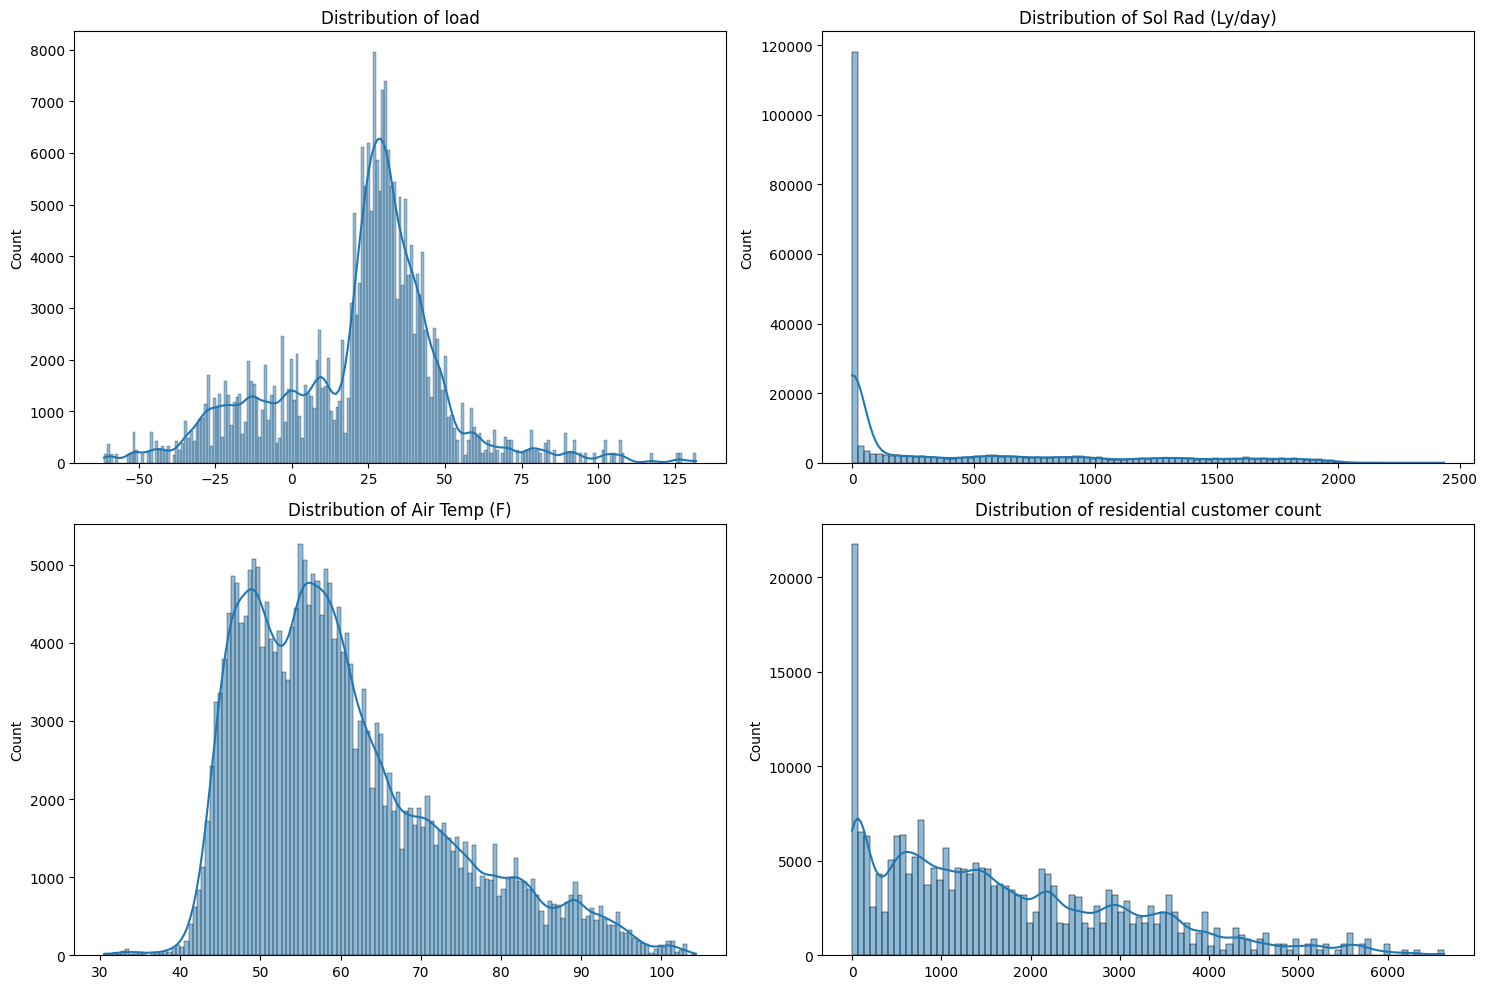

In [ ]:
features_to_plot = [
    'load',
    'Sol Rad (Ly/day)',
    'Air Temp (F)',
    'residential customer count'
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(features_to_plot):
    if feature in X.columns:
        sns.histplot(X[feature], kde=True, ax=axes[idx])
        axes[idx].set_title(f'Distribution of {feature}')
        axes[idx].set_xlabel('')
    else:
        axes[idx].set_visible(False)
        print(f"Warning: feature '{feature}' not found in X.columns")

plt.tight_layout()
plt.show()


The histogram of feeder headroom (mean_ica_sg) shows a strongly right-skewed distribution measured in kilowatts (kW). Most feeder–hour observations are concentrated at relatively low to moderate headroom levels, largely below about 5,000 kW, with the highest density occurring at the lower end of the range. As headroom increases, the frequency of observations declines steadily, forming a long right tail that extends beyond 15,000 kW. This distribution directly motivates our low–high congestion risk cutoff, as a substantial share of feeders operate within the lower headroom range where congestion is more likely. In contrast, only a small subset of feeders exhibit very high available capacity, indicating that elevated headroom is relatively rare across the system.

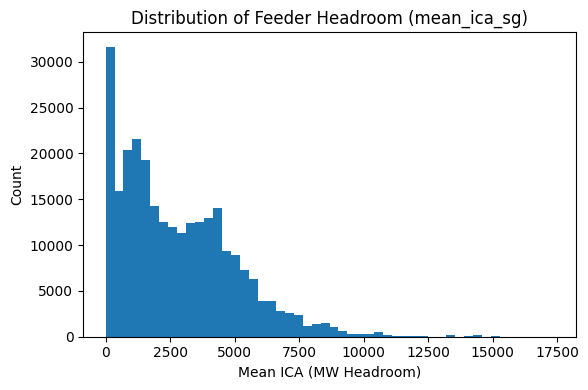

In [ ]:
df = pd.read_csv("outputs/feeder_features_cleaned.csv")

plt.figure(figsize=(6,4))
plt.hist(df["mean_ica_sg"].dropna(), bins=50)
plt.xlabel("Mean ICA (MW Headroom)")
plt.ylabel("Count")
plt.title("Distribution of Feeder Headroom (mean_ica_sg)")
plt.tight_layout()
plt.show()

This figure shows feeder-level congestion rates clustered by ZIP code, with ZIP codes ordered from lowest to highest average congestion. Each dot represents a single feeder, and color intensity reflects congestion severity (blue = low, red = high). The plot reveals that most ZIP codes on the left side are dominated by feeders with near-zero congestion, indicating that congestion is not widespread across the system. In contrast, a small group of ZIP codes on the right exhibits a dense concentration of orange and red points, showing that many feeders in these areas are congested for a large fraction of observed month–hours.

The dashed horizontal line at 50% of hours congested highlights a clear threshold separating moderate from severe congestion. Several ZIP codes contain multiple feeders that lie above this threshold, indicating persistent structural congestion rather than isolated or temporary overloads. At the same time, even within high-risk ZIP codes, there remains noticeable variability across feeders, suggesting that local feeder characteristics still play an important role beyond geographic location alone.

Overall, the figure demonstrates that congestion risk is highly geographically concentrated, with a small subset of ZIP codes accounting for most chronic congestion. This supports a targeted, ZIP-specific and feeder-specific resource allocation strategy, rather than broad system-wide upgrades, and helps identify where engineering review and capital investment would be most impactful.

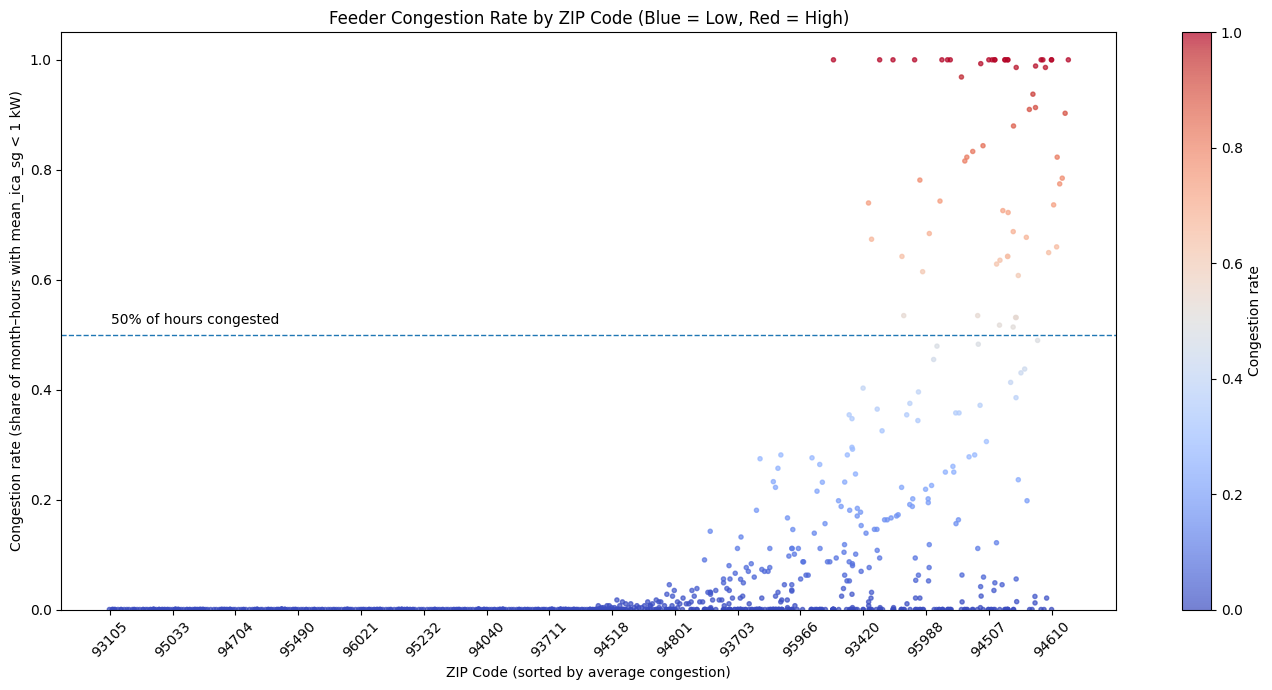

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df["congested"] = (df["mean_ica_sg"] < 1).astype(int)

feeder_stats = (
    df.groupby(["feederid", "ZIP_CODE"])["congested"]
      .agg(["sum", "count"])
      .reset_index()
)
feeder_stats["congestion_rate"] = feeder_stats["sum"] / feeder_stats["count"]
feeder_stats["ZIP_CODE"] = feeder_stats["ZIP_CODE"].astype(str)

# Sort ZIPs by average congestion rate
zip_avg = (
    feeder_stats.groupby("ZIP_CODE")["congestion_rate"]
    .mean()
    .sort_values()
)
sorted_zips = zip_avg.index.tolist()
zip_map = {z: i for i, z in enumerate(sorted_zips)}

feeder_stats["zip_x_base"] = feeder_stats["ZIP_CODE"].map(zip_map)

np.random.seed(42) 
jitter = np.random.uniform(-0.25, 0.25, size=len(feeder_stats))
feeder_stats["zip_x"] = feeder_stats["zip_x_base"] + jitter

plt.figure(figsize=(14, 7))

sc = plt.scatter(
    feeder_stats["zip_x"],
    feeder_stats["congestion_rate"],
    s=9,
    c=feeder_stats["congestion_rate"],
    cmap="coolwarm",   # blue = low, red = high
    alpha=0.7
)

plt.axhline(0.5, linestyle="--", linewidth=1)
plt.text(0.5, 0.52, "50% of hours congested", fontsize=10)

plt.xlabel("ZIP Code (sorted by average congestion)")
plt.ylabel("Congestion rate (share of month–hours with mean_ica_sg < 1 kW)")
plt.title("Feeder Congestion Rate by ZIP Code (Blue = Low, Red = High)")
plt.ylim(0, 1.05)

step = max(1, len(sorted_zips) // 15)
tick_positions = list(range(0, len(sorted_zips), step))
tick_labels = [sorted_zips[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45)

cbar = plt.colorbar(sc)
cbar.set_label("Congestion rate")

plt.tight_layout()
plt.show()

the final feeder_features data frame shows 287424 NA values originating from PG&E's ICA data, which represents only 7% of the total data. These will be dropped when building models but since this is a small
proportion of data, the merged data and merge pipeline frame appears to be structurally sound. Moreover, a histogram of feeder congestion reveals a left-skewed distribution with enough variation to proceed. 


=== feeder_features summary ===
Shape (rows, columns): (287424, 25)
Columns: ['feederid', 'month', 'hour', 'load', 'ZIP_CODE', '2023', '2024', 'YoY Change', '%change', 'loadorgen', 'mean_ica_sg', 'nominal voltage (kv)', 'redacted data', 'residential customer count', 'commercial customer count', 'industrial customer count', 'agricultural customer count', 'other customers', 'existing distributed generation (kw)', 'queued distributed generation (kw)', 'total distributed generation (kw)', 'voltage', 'Sol Rad (Ly/day)', 'Air Temp (F)', 'Wind Speed (mph)']

Head of final dataframe:


,feederid,month,hour,load,ZIP_CODE,2023,2024,YoY Change,%change,loadorgen,...,industrial customer count,agricultural customer count,other customers,existing distributed generation (kw),queued distributed generation (kw),total distributed generation (kw),voltage,Sol Rad (Ly/day),Air Temp (F),Wind Speed (mph)
0,102041103,1.0,0.0,34.147932,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,47.439,3.852
1,102041103,1.0,1.0,32.083565,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,47.174,3.587
2,102041103,1.0,2.0,30.885029,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,46.919,3.945
3,102041103,1.0,3.0,30.658824,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,46.755,4.213
4,102041103,1.0,4.0,31.625994,95928,610.0,727.0,117.0,0.191803,G,...,162,2,9.0,6030,4200,10230,12,0.0,46.726,4.129



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287424 entries, 0 to 287423
Data columns (total 25 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   feederid                              287424 non-null  object 
 1   month                                 287424 non-null  float64
 2   hour                                  287424 non-null  float64
 3   load                                  287424 non-null  float64
 4   ZIP_CODE                              287424 non-null  object 
 5   2023                                  285696 non-null  float64
 6   2024                                  285984 non-null  float64
 7   YoY Change                            286272 non-null  float64
 8   %change                               285696 non-null  float64
 9   loadorgen                             266258 non-null  object 
 10  mean_ica_sg                           266258 non-null  float6

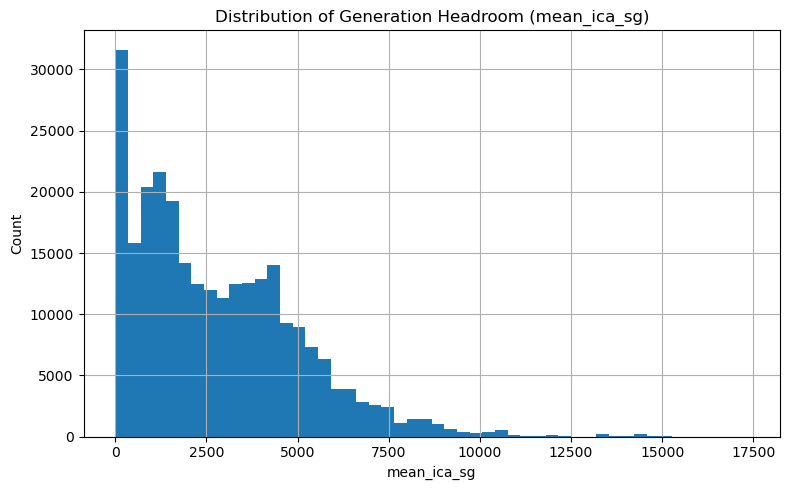


Unique months in final data: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0)]
Unique hours in final data: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0)]


In [ ]:
import matplotlib.pyplot as plt


# check feeder_features structure
print("\n=== feeder_features summary ===")
print("Shape (rows, columns):", feeder_features.shape)
print("Columns:", feeder_features.columns.tolist())

print("\nHead of final dataframe:")
display(feeder_features.head())

print("\nInfo:")
feeder_features.info()

# check loadorgen counts
if "loadorgen" in feeder_features.columns:
    print("\nloadorgen value counts:")
    print(feeder_features["loadorgen"].value_counts(dropna=False))

if "mean_ica_sg" in feeder_features.columns:
    print("\nmean_ica_sg summary stats:")
    print(feeder_features["mean_ica_sg"].describe())


# check for month/hour coverage
if {"month", "hour"}.issubset(feeder_features.columns):
    print("\nUnique months in final data:", sorted(feeder_features["month"].dropna().unique()))
    print("Unique hours in final data:", sorted(feeder_features["hour"].dropna().unique()))

### Checking spatial coverage of feeder_features data fram
The maps generated below show full coverage of PG&E feeder IDs from the feeder shapefiles, compared with the feeders in our final feeder_features data frame. Comparing te number of feeders in PG&E shapefiles with the feeders present in feeder_features reveals that abbroximately 2/3 of feeders are not in the final data frame. This is likely due to rural feeders not falling within California regions with Zip codes or due to the feeders not falling within one of the climate zones used in the CALMAC load profiles data. Despite this, more than 900 unique feeders are in the final data frame, which will provide enough data to model.We also constructed a heatmap which shows the distribution of feeder congestion across remaining feeders, as calculated by mean_ica_sg. this maps reveals ample spatial distribution of feeders and congestion within the feeder_features data frame, with plenty of distribution across climate zone.

Feeder geometries in shapefile: 3023
Feeders in feeder_features:    989
Feeders with both geometry and ICA: 930


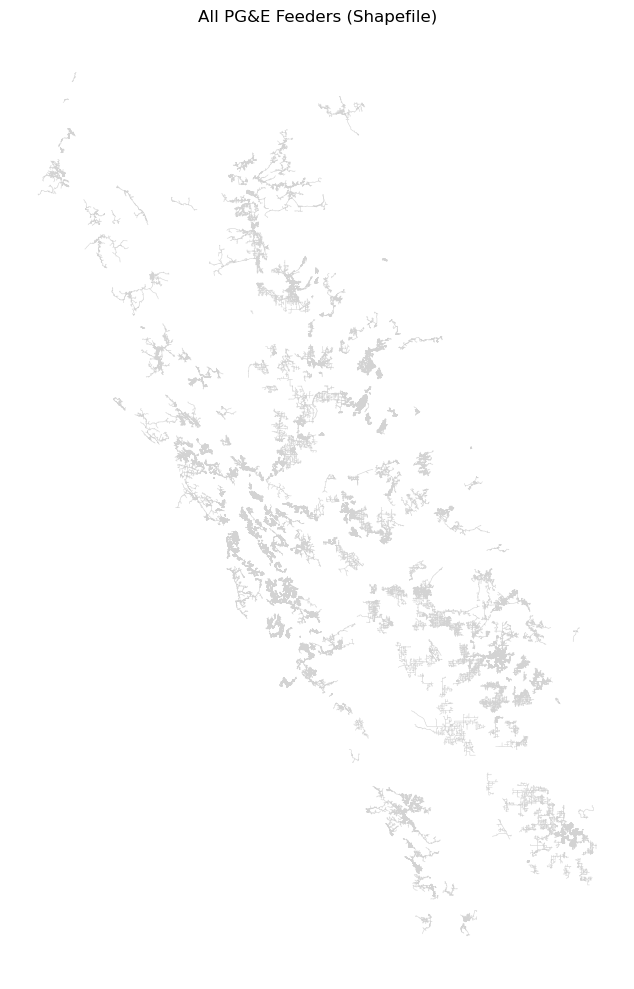

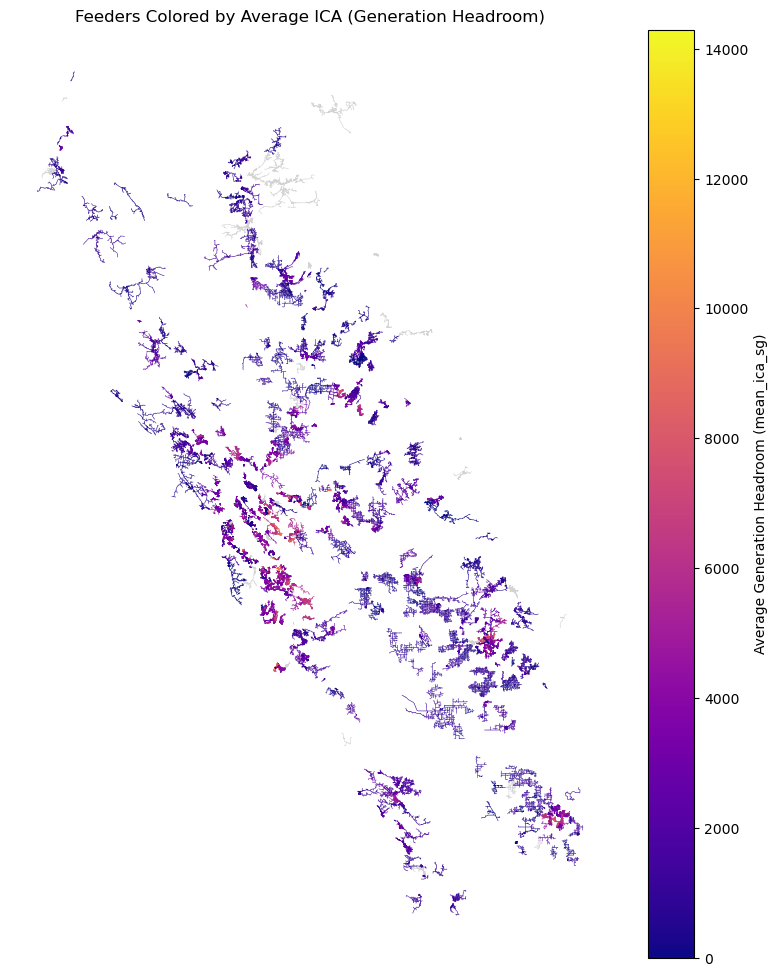

In [31]:


# Check coverage of resulting feeders and distribution of mean_ica_sg (congestion)
# Load feeder shapefile
feeders = gpd.read_file("ica_data/FeederDetail_Voltage.shp")
feeders["feederid"] = normalize_feederid(feeders["feederid"])

# aggregate congestion accross each feeder
if "mean_ica_sg" in feeder_features.columns:
    ff_unique = (
        feeder_features
        .groupby("feederid", as_index=False)["mean_ica_sg"]
        .mean()
    )
else:
    raise ValueError("mean_ica_sg not found in feeder_features; cannot plot ICA heatmap.")

# Merge geometries with ICA summary
feeders_merged = feeders.merge(ff_unique, on="feederid", how="left")

# Coverage diagnostics
n_geom = feeders["feederid"].nunique()
n_ff = feeder_features["feederid"].nunique()
n_with_ica_geom = feeders_merged.loc[
    feeders_merged["mean_ica_sg"].notna(), "feederid"
].nunique()

print(f"Feeder geometries in shapefile: {n_geom}")
print(f"Feeders in feeder_features:    {n_ff}")
print(f"Feeders with both geometry and ICA: {n_with_ica_geom}")

# Map all feeders
fig, ax = plt.subplots(figsize=(8, 10))
feeders.plot(ax=ax, color="lightgray", linewidth=0.4)
ax.set_title("All PG&E Feeders (Shapefile)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

# heat-map congestion
fig, ax = plt.subplots(figsize=(8, 10))
feeders_merged.plot(
    ax=ax,
    column="mean_ica_sg",
    cmap="plasma",
    legend=True,
    legend_kwds={"label": "Average Generation Headroom (mean_ica_sg)"},
    linewidth=0.4,
    missing_kwds={"color": "lightgray", "label": "No ICA data"},
)
ax.set_title("Feeders Colored by Average ICA (Generation Headroom)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

EV adoption increased across most of California from 2023 to 2024. Statewide, 80% of ZIP codes saw positive EV growth, while only about 6% showed declines. When weighted by the size of each ZIP’s existing EV population, California experienced a 25% overall increase in EV adoption year-over-year. The absolute EV counts reinforce this trend, showing that 2024 levels exceed 2023 nearly everywhere, while a handful of dense ZIPs still dominate total volumes.
Although our selected feeders represent only a small subset of these ZIPs, analyzing the full statewide distribution is critical. It reveals how broad and diffuse EV growth has become, highlights the tail-risk of rapid adoption pockets, and demonstrates why our modeling methodology must be robust at both the local and statewide scale. This broader context strengthens the generalizability and long-term relevance of our approach. See below for two charts demonstrating this. 


Average YoY Growth: 40.98%


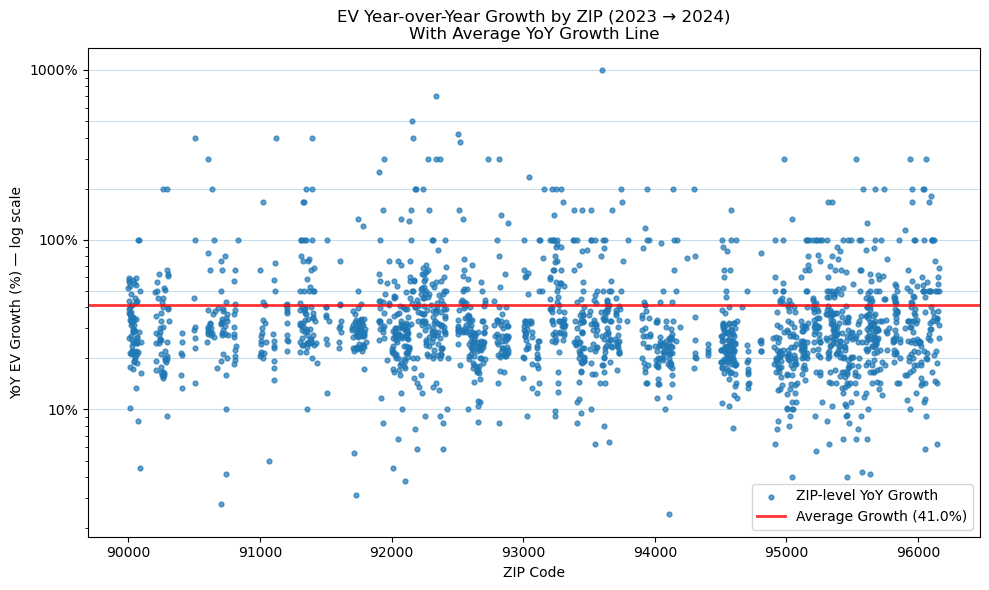

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# 1. Load data
df = pd.read_csv("EV_Pop_Growth_23_24.csv")

# 2. Keep only positive YoY growth
df_filtered = df[df["%change"] > 0].copy()

# 3. Convert fractional YoY values to percent
df_filtered["YoY_percent"] = df_filtered["%change"] * 100

# 4. Compute the mean YoY growth (%)
mean_growth = df_filtered["YoY_percent"].mean()

print(f"Average YoY Growth: {mean_growth:.2f}%") 

# 5. Percentage formatter for log-scale y-axis
def percent_formatter(x, pos):
    return f"{x:.0f}%"

formatter = FuncFormatter(percent_formatter)

# 6. Plot
plt.figure(figsize=(10,6))

plt.scatter(
    df_filtered["Zip Code"],
    df_filtered["YoY_percent"],
    s=12,
    alpha=0.7,
    label="ZIP-level YoY Growth"
)

plt.yscale("log")
plt.gca().yaxis.set_major_formatter(formatter)

# --- Add the average line ---
plt.axhline(
    mean_growth,
    color="red",
    linestyle="-",
    linewidth=2,
    alpha=0.8,
    label=f"Average Growth ({mean_growth:.1f}%)"
)

# Optional reference gridlines
for ref in [10, 20, 50, 100, 200, 500, 1000]:
    plt.axhline(ref, linestyle="-", linewidth=0.6, alpha=0.3)

plt.xlabel("ZIP Code")
plt.ylabel("YoY EV Growth (%) — log scale")
plt.title("EV Year-over-Year Growth by ZIP (2023 → 2024)\nWith Average YoY Growth Line")

plt.legend()
plt.tight_layout()
plt.show()

Average 2023 EVs per ZIP: 659.3
Average 2024 EVs per ZIP: 810.0


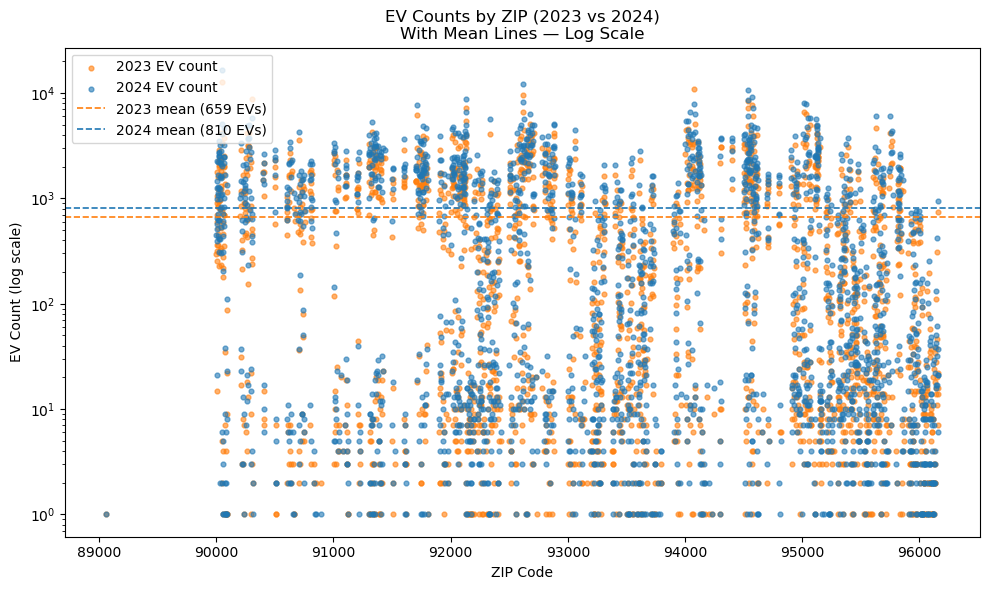

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv("EV_Pop_Growth_23_24.csv") 

# 2. Extract columns
zips = df["Zip Code"]
ev_2023 = df["2023"]
ev_2024 = df["2024"]

# 3. Compute means
mean_2023 = ev_2023.mean()
mean_2024 = ev_2024.mean()

print(f"Average 2023 EVs per ZIP: {mean_2023:.1f}")
print(f"Average 2024 EVs per ZIP: {mean_2024:.1f}")

# 4. Plot (with log scale)
plt.figure(figsize=(10, 6))

# Scatter: EV counts
plt.scatter(
    zips,
    ev_2023,
    s=12,
    alpha=0.6,
    color="tab:orange",
    label="2023 EV count"
)

# Scatter: 2024 EV counts
plt.scatter(
    zips,
    ev_2024,
    s=12,
    alpha=0.6,
    color="tab:blue",
    label="2024 EV count"
)

# 5. Add average lines 
plt.axhline(
    mean_2023,
    color="tab:orange",
    linestyle="--",
    linewidth=1.2,
    label=f"2023 mean ({mean_2023:.0f} EVs)"
)

plt.axhline(
    mean_2024,
    color="tab:blue",
    linestyle="--",
    linewidth=1.2,
    label=f"2024 mean ({mean_2024:.0f} EVs)"
)

# 6. Log scale for Y axis
plt.yscale("log")

plt.xlabel("ZIP Code")
plt.ylabel("EV Count (log scale)")
plt.title("EV Counts by ZIP (2023 vs 2024)\nWith Mean Lines — Log Scale")
plt.legend()
plt.tight_layout()
plt.show()



## Forecasting and Prediction Modeling (25 points)

This section is where the rubber meets the road.  In it you must:
1. Explore at least 3 prediction modeling approaches for each prediction question, ranging from the simple (e.g. linear regression, KNN) to the complex (e.g. SVM, random forests, Lasso).  
2. Motivate all your modeling decisions.  This includes parameter choices (e.g., how many folds in k-fold cross validation, what time window you use for averaging your data) as well as model form (e.g., If you use regression trees, why?  If you include nonlinear features in a regression model, why?). 
1. Carefully describe your cross validation and model selection process.  You should partition your data into training and testing data sets.  The training data set is what you use for cross-validation (i.e. you sample from within it to create folds, etc.).  The testing data set is held to the very end of your efforts, and used to compare qualitatively different models (e.g. OLS vs random forests).
4. Very carefully document your workflow.  We will be reading a lot of projects, so we need you to explain each basic step in your analysis.  
5. Seek opportunities to write functions allow you to avoid doing things over and over, and that make your code more succinct and readable. 

#### Prediction model 1: Regression:

##### Motivation and Model Selection:

For this prediction problem, we frame feeder congestion as a continuous regression task at the feeder–month–hour level. The target variable is the available headroom in MW (mean_ica_sg), interpreted as the remaining solar hosting capacity on each feeder at a given month–hour. Our feature set combines relatively static feeder attributes (e.g., voltage class, existing distributed generation, customer mix) with more dynamic temporal and environmental variables (month, hour, system load, and weather). The core goal is to estimate “How much headroom will this feeder have at month–hour?”, so that planners can identify feeders where capacity is tightening over time and evaluate the impacts of future DER or load-growth scenarios.

We explore three main families of regression models that span the complexity spectrum: OLS as a simple linear baseline, regularized linear models (Ridge and Lasso regression), and a Random Forest regressor as a flexible, non-linear ensemble model. To evaluate and select models, we partitioned the data into a training set and a held-out test set using an 80/20 split. The training set is used exclusively for model fitting and cross-validation, if that was included on the model, while the test set is held out until the very end for a one-time comparison of final model performance. All linear models (OLS, Ridge, Lasso) are standardized using StandardScaler so that features are on comparable scales. This is especially important for Ridge and Lasso, whose penalties depend on the scale of the coefficients. The Random Forest model does not use standardization, because tree-based models are inherently scale-invariant.

Within the training data for Ridge, Lasso, and Random Forest models, we use k-fold cross-validation (10-folds) to tune hyperparameters and estimate out-of-sample error. For Ridge and Lasso, we cross-validated to select the α that minimizes the average Root Mean Squared Error (RMSE) across folds. For the Random Forest, we tuned a small set of key hyperparameters, including the number of trees and maximum depth, to balance predictive performance against training time. Our primary selection metric is RMSE, since it has the same units as the target (MW headroom) and penalizes larger errors more strongly, although we also report MAE and R² to provide additional context.

Before fitting models, we performed basic feature screening to improve the potential predictive power of models generated. We restricted the predictor set to numeric variables (excluding the target), identified any strictly categorical columns for potential encoding or exclusion, and then computed pairwise correlations and Variance Inflation Factors (VIF) to flag highly collinear predictors. Predictors with extremely high correlation or VIF values are considered for removal in order to reduce instability in OLS and to make the Ridge and Lasso penalties more meaningful. This preprocessing step is implemented in a short diagnostic script that prints detected categorical variables and VIF-based drop candidates.


Shape: (266258, 25)
Columns: ['feederid', 'month', 'hour', 'load', 'ZIP_CODE', '2023', '2024', 'YoY Change', '%change', 'loadorgen', 'mean_ica_sg', 'Sol Rad (Ly/day)', 'Air Temp (F)', 'Wind Speed (mph)', 'nominal voltage (kv)', 'redacted data', 'residential customer count', 'commercial customer count', 'industrial customer count', 'agricultural customer count', 'other customers', 'existing distributed generation (kw)', 'queued distributed generation (kw)', 'total distributed generation (kw)', 'voltage']
Shape after dropping NaNs: (235379, 25)


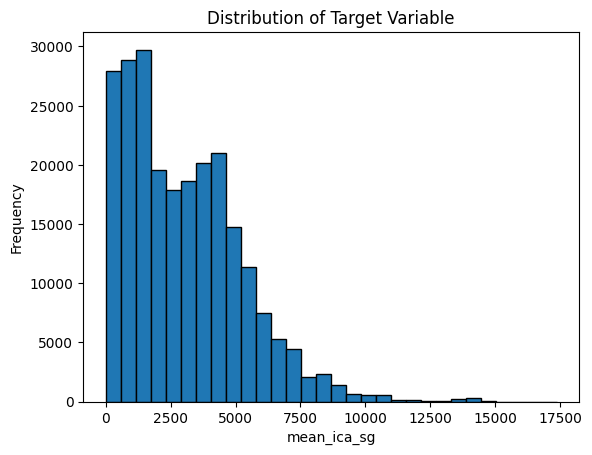


Categorical variables:
['loadorgen', 'nominal voltage (kv)', 'redacted data']

Numeric variables:
['feederid', 'month', 'hour', 'load', 'ZIP_CODE', '2023', '2024', 'YoY Change', '%change', 'Sol Rad (Ly/day)', 'Air Temp (F)', 'Wind Speed (mph)', 'residential customer count', 'commercial customer count', 'industrial customer count', 'agricultural customer count', 'other customers', 'existing distributed generation (kw)', 'queued distributed generation (kw)', 'total distributed generation (kw)', 'voltage']


/Users/phealy92/Library/Python/3.9/lib/python/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



VIF scores:
                                 feature        VIF
17  existing distributed generation (kw)        inf
19     total distributed generation (kw)        inf
5                                   2023        inf
6                                   2024        inf
7                             YoY Change        inf
18    queued distributed generation (kw)        inf
4                               ZIP_CODE  59.738039
9                       Sol Rad (Ly/day)   8.843746
3                                   load   5.471105
0                               feederid   4.994572
10                          Air Temp (F)   3.812297
13             commercial customer count   3.343842
14             industrial customer count   2.953522
12            residential customer count   2.255829
20                               voltage   1.685752
11                      Wind Speed (mph)   1.650039
16                       other customers   1.569475
8                                %change   1.428101

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor


# load data
DATA_PATH = "/Users/phealy92/CascadeProjects/Predicted-Feeder-Congestion/outputs/feeder_features_cleaned.csv"
TARGET_COL = "mean_ica_sg"


df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print("Columns:", df.columns.tolist())


# drop rows with missing values (diagnostics only)
df_clean = df.dropna()
print("Shape after dropping NaNs:", df_clean.shape)


# histogram of target variable distribution
plt.hist(df_clean[TARGET_COL], bins=30, edgecolor='black')
plt.title("Distribution of Target Variable")
plt.xlabel(TARGET_COL)
plt.ylabel("Frequency")
plt.show()


# identify categorical variables
categorical_vars = df_clean.select_dtypes(include=["object", "category"]).columns.tolist()
print("\nCategorical variables:")
print(categorical_vars if categorical_vars else "None")


# identify numeric variables (exclude target)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET_COL]
print("\nNumeric variables:")
print(numeric_cols)


# VIF collinearity check
X_num = df_clean[numeric_cols].astype(float)
vif_data = []


for i, col in enumerate(numeric_cols):
   vif_val = variance_inflation_factor(X_num.values, i)
   vif_data.append((col, vif_val))


vif_df = pd.DataFrame(vif_data, columns=["feature", "VIF"]).sort_values("VIF", ascending=False)
print("\nVIF scores:")
print(vif_df)


vif_threshold = 10
vif_drop_candidates = vif_df.loc[vif_df["VIF"] > vif_threshold, "feature"].tolist()


print(f"\nSuggested drops from VIF > {vif_threshold}:")
print(vif_drop_candidates if vif_drop_candidates else "None")


# summary
print("\nSummary")
print("Categorical variables:", categorical_vars)
print("VIF-based drop candidates:", vif_drop_candidates if vif_drop_candidates else [])


From this output, we noticed that columns for '2023', '2024', and 'YoY Change' were perfectly collinear, so we decided to remove the ‘2023’ and ‘2024’ columns. We also noticed that 'existing distributed generation (kw)', 'queued distributed generation (kw)', and 'total distributed generation (kw)' were perfectly collinear, and because we were using static data, we decided to use just ‘existing distributed generation (kw)' and remove 'queued distributed generation (kw)', and 'total distributed generation (kw)' columns. Columns ‘loadorgen’ and ‘redacted data’ were identified as categorical features that served little predictive purpose, so they were removed. It was recognized that the feature column ‘nominal voltage’ was redundant with ‘voltage’, so nominal voltage was removed. Finally, ‘ZIP_CODE’ had a high VIF, and after discussing with the team, it was decided that this feature had little contribution to the model, as the geographic location of a feature probably does not contribute predictive power in a model with weather data and load shapes.

OLS provides a transparent starting point that assumes a linear relationship between headroom and the predictors and is easy to interpret in terms of marginal effects. Each coefficient represents the expected change in ICA headroom for a one-unit change in the corresponding feature, holding all other features constant. This makes OLS especially useful for initial model exploration, diagnosing multicollinearity, and identifying which operational or weather variables are most strongly associated with feeder congestion. However, OLS also relies on assumptions such as linearity, homoscedasticity, and lack of strong collinearity; violations of these assumptions may lead to biased standard errors or unstable coefficient estimates. As a result, while OLS offers interpretability and serves as a useful baseline model, it may need to be supplemented with regularization, nonlinear models, or feature engineering to better capture the complex dynamics driving ICA headroom. 
Three linear models (ordinary least squares, Ridge, and Lasso regression) produced nearly identical performance, with RMSE values around 1501 MW, MAE values near 1124 MW, and an R² of approximately 0.56, showing that linear relationships explain only about half of the variability in mean MW headroom. In contrast, the Random Forest model performed substantially better, achieving an RMSE of 240 MW, an MAE of 106 MW, and an R² of 0.989. This large improvement indicates that mean feeder headroom is governed by strong nonlinear relationships among load, time, weather, customer composition, and distributed generation, which are effectively captured by the Random Forest but not by linear models.

In [ ]:
import numpy as np
import pandas as pd


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# load dataset and define target feature
DATA_PATH = "/Users/phealy92/CascadeProjects/Predicted-Feeder-Congestion/outputs/feeder_features_cleaned_PhillipEdits_v2.csv"
TARGET_COL = "mean_ica_sg"


df = pd.read_csv(DATA_PATH)


# define feature columns as all numeric columns except the target
feature_cols = [
   col for col in df.select_dtypes(include=[np.number]).columns
   if col != TARGET_COL
]


print("Using numeric feature columns:")
print(feature_cols)


# drop rows with missing values in features or target
df_clean = df.dropna(subset=feature_cols + [TARGET_COL])


# define feature matrix and target variable
X = df_clean[feature_cols]
y = df_clean[TARGET_COL]


# train-test split
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42
)


# OLS Regression Model (no pipeline)
model = LinearRegression()
model.fit(X_train, y_train)


# evaluate model on test set
y_pred = model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print("\nOLS Regression Results")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")


# extract coefficients (same order as feature_cols)
coef = model.coef_


coef_df = pd.DataFrame({
   "feature": feature_cols,
   "coefficient": coef
})


print("\nCoefficients")
print(coef_df.sort_values("coefficient", ascending=False))


Using numeric feature columns:
['feederid', 'month', 'hour', 'load', '2024', 'Sol Rad (Ly/day)', 'Air Temp (F)', 'Wind Speed (mph)', 'residential customer count', 'commercial customer count', 'industrial customer count', 'agricultural customer count', 'other customers', 'existing distributed generation (kw)', 'queued distributed generation (kw)', 'total distributed generation (kw)', 'voltage']

OLS Regression Results
RMSE: 1500.958
R²:   0.556

Coefficients
                                 feature  coefficient
16                               voltage   253.929570
10             industrial customer count    13.411032
3                                   load    10.937584
6                           Air Temp (F)     9.402767
7                       Wind Speed (mph)     8.276348
2                                   hour     2.358447
12                       other customers     0.662437
4                                   2024     0.263175
8             residential customer count     0.15107

/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


To attempt to address this, we employed the use of regularization models: Ridge regression to stabilize coefficient estimates in the presence of collinearity and Lasso regression to perform implicit feature selection by shrinking some coefficients toward zero. 

During Lasso runs, scikit-learn raises “RuntimeWarning” messages about overflow and invalid values in matrix multiplication. This indicates that for some combinations of features and regularization strength, the optimization problem was numerically unstable: coefficients grew extremely large, leading to infinite or undefined predictions. This would suggest that predictions with lasso had low utility, and that Lasso is probably not an appropriate model for this dataframe.

In [ ]:
import numpy as np
import pandas as pd


from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


# load dataset and define target feature
DATA_PATH = "/Users/phealy92/CascadeProjects/Predicted-Feeder-Congestion/outputs/feeder_features_cleaned_PhillipEdits_v2.csv"
TARGET_COL = "mean_ica_sg"


df = pd.read_csv(DATA_PATH)


# define feature columns as all numeric columns except the target
feature_cols = [
   col for col in df.select_dtypes(include=[np.number]).columns
   if col != TARGET_COL
]


print("Using numeric feature columns:")
print(feature_cols)


# drop rows with missing values in features or target
df_clean = df.dropna(subset=feature_cols + [TARGET_COL])


# define feature matrix and target variable
X = df_clean[feature_cols]
y = df_clean[TARGET_COL]


# train-test split
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42
)


# scale features (critical for Ridge/Lasso stability)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# sanity check for numerical issues after scaling
assert np.isfinite(X_train_scaled).all(), "Non-finite values in X_train_scaled"
assert np.isfinite(X_test_scaled).all(), "Non-finite values in X_test_scaled"


# helper function to compute RMSE via k-fold cross-validation
def cv_rmse(model, X, y, n_splits=5):
   kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
   neg_mse_scores = cross_val_score(
       model, X, y,
       scoring="neg_mean_squared_error",
       cv=kf
   )
   mse_scores = -neg_mse_scores
   return np.sqrt(mse_scores.mean())


# ridge regression with CV over alpha
ridge_alphas = np.logspace(-3, 3, 20)  # from 0.001 to 1000


best_ridge_alpha = None
best_ridge_rmse = np.inf


for a in ridge_alphas:
   ridge = Ridge(alpha=a, max_iter=10000)
   rmse = cv_rmse(ridge, X_train_scaled, y_train)
   if rmse < best_ridge_rmse:
       best_ridge_rmse = rmse
       best_ridge_alpha = a


print(f"\nBest Ridge alpha: {best_ridge_alpha}")
print(f"Ridge CV RMSE: {best_ridge_rmse:.3f}")


# fit final ridge model on full training data
best_ridge = Ridge(alpha=best_ridge_alpha, max_iter=10000)
best_ridge.fit(X_train_scaled, y_train)


# evaluate ridge on test set
y_pred_ridge = best_ridge.predict(X_test_scaled)
ridge_test_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_test_rmse = np.sqrt(ridge_test_mse)
ridge_test_r2 = r2_score(y_test, y_pred_ridge)


print("\nRidge Test Results")
print(f"Test RMSE: {ridge_test_rmse:.3f}")
print(f"Test R²:   {ridge_test_r2:.3f}")


# lasso regression with CV over alpha
lasso_alphas = np.logspace(-3, 1, 20)  # from 0.001 to 10


best_lasso_alpha = None
best_lasso_rmse = np.inf


for a in lasso_alphas:
   lasso = Lasso(alpha=a, max_iter=10000)
   rmse = cv_rmse(lasso, X_train_scaled, y_train)
   if rmse < best_lasso_rmse:
       best_lasso_rmse = rmse
       best_lasso_alpha = a


print(f"\nBest Lasso alpha: {best_lasso_alpha}")
print(f"Lasso CV RMSE: {best_lasso_rmse:.3f}")


# fit final lasso model on full training data
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)


# evaluate lasso on test set
y_pred_lasso = best_lasso.predict(X_test_scaled)
lasso_test_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_test_rmse = np.sqrt(lasso_test_mse)
lasso_test_r2 = r2_score(y_test, y_pred_lasso)


print("\nLasso Test Results")
print(f"Test RMSE: {lasso_test_rmse:.3f}")
print(f"Test R²:   {lasso_test_r2:.3f}")


# lasso coefficients (on standardized features)
lasso_coef = best_lasso.coef_
coef_df = pd.DataFrame({
   "feature": feature_cols,  # same order as columns in X
   "coefficient": lasso_coef
})


print("\nLasso Coefficients")
print(coef_df.sort_values("coefficient", ascending=False))


Using numeric feature columns:
['feederid', 'month', 'hour', 'load', '2024', 'Sol Rad (Ly/day)', 'Air Temp (F)', 'Wind Speed (mph)', 'residential customer count', 'commercial customer count', 'industrial customer count', 'agricultural customer count', 'other customers', 'existing distributed generation (kw)', 'queued distributed generation (kw)', 'total distributed generation (kw)', 'voltage']


/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self


Best Ridge alpha: 26.366508987303554
Ridge CV RMSE: 1493.069

Ridge Test Results
Test RMSE: 1500.956
Test R²:   0.556


/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.p


Best Lasso alpha: 0.011288378916846888
Lasso CV RMSE: 1493.069

Lasso Test Results
Test RMSE: 1500.957
Test R²:   0.556

Lasso Coefficients
                                 feature  coefficient
16                               voltage  1155.760794
10             industrial customer count   663.998213
4                                   2024   462.239766
3                                   load   299.522009
8             residential customer count   215.534087
6                           Air Temp (F)   118.889078
15     total distributed generation (kw)    41.776036
5                       Sol Rad (Ly/day)    40.594893
2                                   hour    16.371529
7                       Wind Speed (mph)    15.181900
12                       other customers     6.064747
1                                  month   -14.608408
13  existing distributed generation (kw)  -133.693909
0                               feederid  -195.041815
14    queued distributed generation (kw)  -257.95

/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Finally, we include a Random Forest model to capture non-linearities and higher-order interactions (e.g., between load, customer mix, and weather) that are unlikely to be well-approximated by a purely linear model.

Using numeric feature columns:
['feederid', 'month', 'hour', 'load', '2024', 'Sol Rad (Ly/day)', 'Air Temp (F)', 'Wind Speed (mph)', 'residential customer count', 'commercial customer count', 'industrial customer count', 'agricultural customer count', 'other customers', 'existing distributed generation (kw)', 'queued distributed generation (kw)', 'total distributed generation (kw)', 'voltage']

Random Forest 10-Fold CV on Training Set
RMSE scores: [237.88893846 260.23150357 243.84574604 239.61444242 246.97824721
 229.91397025 232.55531434 236.61959053 241.82737946 242.04366396]
Mean RMSE: 241.152
Std  RMSE: 8.001

Random Forest Test Results
RMSE: 240.251
R²:   0.989


<Figure size 1000x600 with 0 Axes>

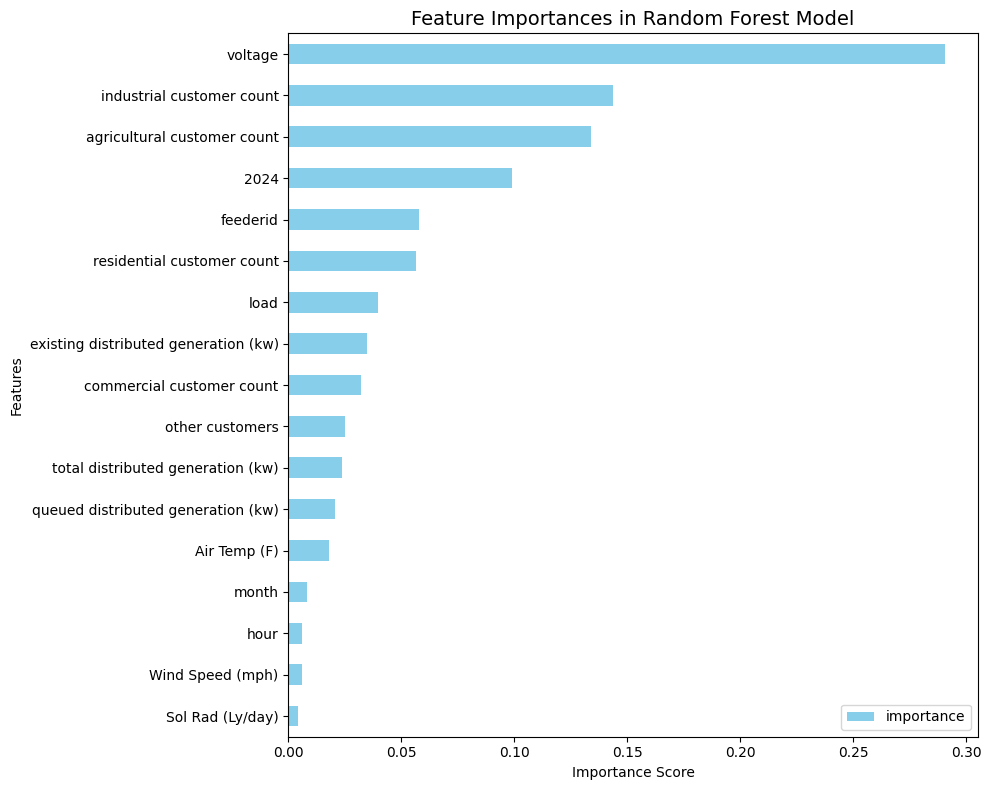

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


# load dataset and define target feature
DATA_PATH = "/Users/phealy92/CascadeProjects/Predicted-Feeder-Congestion/outputs/feeder_features_cleaned_PhillipEdits_v2.csv"
TARGET_COL = "mean_ica_sg"   # change to "min_ica_sg" if you want


df = pd.read_csv(DATA_PATH)


# use all numeric columns except the target as features
feature_cols = [
   col for col in df.select_dtypes(include=[np.number]).columns
   if col != TARGET_COL
]


print("Using numeric feature columns:")
print(feature_cols)


# drop rows with missing values in features or target
df_clean = df.dropna(subset=feature_cols + [TARGET_COL])


X = df_clean[feature_cols]
y = df_clean[TARGET_COL]


# train-test split
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42
)


# random forest model
rf = RandomForestRegressor(
   n_estimators=300,
   max_depth=None,
   random_state=42,
   n_jobs=-1
)


# 10-fold cross-validation on the training set
kfold = KFold(n_splits=10, shuffle=True, random_state=42)


# scoring='neg_root_mean_squared_error'; negative RMSE, so take the negative
cv_scores = cross_val_score(
   rf,
   X_train,
   y_train,
   cv=kfold,
   scoring="neg_root_mean_squared_error",
   n_jobs=-1
)


cv_rmse = -cv_scores  # make positive; cross_val_score returns negative values


print("\nRandom Forest 10-Fold CV on Training Set")
print("RMSE scores:", cv_rmse)
print(f"Mean RMSE: {cv_rmse.mean():.3f}")
print(f"Std  RMSE: {cv_rmse.std():.3f}")


# fit model on training data
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print("\nRandom Forest Test Results")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")


# evaluate feature importances
importances = rf.feature_importances_


feat_imp_df = pd.DataFrame({
   "feature": feature_cols,
   "importance": importances
}).sort_values("importance", ascending=False)


# create feature importance plot
plt.figure(figsize=(10, 6))
feat_imp_df.sort_values('importance', ascending=True).plot.barh(
   x='feature',
   y='importance',
   color='skyblue',
   figsize=(10, 8)
)


# feature importance plot labels and title
plt.title('Feature Importances in Random Forest Model', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()


# show the plot
plt.show()


Here is a summary table of the RMSE and R2 values for each of the models:

| Model          | Test RMSE (kW) | Test R² |
|----------------|----------------|---------|
| OLS            | 1518.6         | 0.545   |
| Ridge Reg.     | 1518.6         | 0.545   |
| Lasso Reg.     | 1518.6         | 0.545   |
| RF Regression  | 240.5          | 0.989   |

The Random Forest model is the only model from the above four models tested that can predict feeder headroom while explaining variation. Using RF, we can predict feeder headroom at any month–hour with an average error of 240 kW. The other models have far less explanatory power and a RMSE that exceeds 1.5 MW, which is not useful since we later define feeder congestion as being < 1 MW of headroom. The RF regression model explains 98.9% of the variation in ICA headroom and therefore provides a reliable estimate for operational decision-making. Linear models (OLS, Ridge, Lasso) are not trustworthy for this task due to severe instability and poor performance.

A final interesting note is that based on the feature analysis of the RF regression model, weather data seemed to have little influence on the model, suggesting that this could be left out in a more refined model.

#### Prediction model 2: Binary Classification:

##### Motivation and Model Selection:

To predict whether a feeder becomes congested (below 1 MW of headroom), we tested a mix of simple and complex models: Logistic Regression (two versions), Linear SVM, KNN, and Random Forest. We wanted to see how far simple linear models could go before switching to more flexible nonlinear approaches:

Logistic Regression (Default, Ridge / L2):

We used logistic regression as our starting baseline model because it is simple and easy to interpret. It allows us to clearly see how each feature is related to congestion risk, which makes it helpful for understanding general trends in the data.

Logistic Regression (C = 10, Weaker Regularization):

This version of logistic regression is a less constrained version of the baseline model. By allowing the model to fit the training data more closely, we tested whether reducing the regularization would improve predictions. 

Support Vector Machine (SVM)

The SVM looks for the best separating boundary between congested and non-congested feeders by maximizing the margin between the two groups. 

Random Forest 

The Random Forest model combines many decision trees to make a final prediction. We included this model because feeder congestion is influenced by interacting physical and behavioral factors, which simple linear models cannot fully represent.

K-Nearest Neighbors (KNN)

The KNN model makes predictions by looking at the most similar past observations and using their outcomes to classify new cases. 

##### Data Processing:

Before training any models, we spent time preparing the data so that all models would be learning from clean, comparable, and reliable inputs. Since our dataset contains a mix of numerical and categorical features (such as weather variables, customer counts, and distributed generation), we first converted all categorical variables into numeric form using one-hot encoding. This step allows the models to interpret categories mathematically rather than as text.

Next, we addressed missing values, which are unavoidable in real-world operational datasets. Instead of discarding large portions of the data, we used median imputation to fill in missing numerical values. 

After splitting the data into training (80%) and testing (20%) sets, we applied standardization only after the split to avoid information leakage. Using StandardScaler, we transformed each numerical feature so that it had a "mean of 0 and a standard deviation of 1", based solely on the training data. This step is especially important for models like Logistic Regression, SVM, and KNN, which are sensitive to differences in feature scale. Without standardization, variables such as distributed generation (measured in thousands of kW) would dominate smaller-scale features like wind speed or temperature, leading to biased learning.



##### Hyperparameter Tuning:

To move beyond purely default model settings, we performed light but principled hyperparameter tuning on our main predictive models. For Logistic Regression, we evaluated two values of the regularization parameter C: the default C = 1, which applies moderate Ridge (L2) regularization to prevent overfitting, and a weaker regularization setting C = 10, which allows the model to fit the data more closely. For the Random Forest, we tuned the number of trees (100 and 200), the maximum tree depth (None, 10, and 20), and the minimum number of samples per leaf (1 and 5) using 3-fold cross-validation on the training set, selecting the configuration that maximized recall for congested feeders. For K-Nearest Neighbors (KNN), we tuned the number of neighbors (5, 10, 15, 20, and 30), again using recall as the selection metric. Smaller values of k capture highly local behavior but are more sensitive to noise, while larger values smooth predictions across broader operating conditions. By selecting k through cross-validation, we ensured that the final KNN model reflects a principled balance between bias and variances. The Linear SVM was evaluated using standard regularization settings to serve as an additional linear baseline for comparison against the nonlinear models.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

df = pd.read_csv("/Users/phealy92/CascadeProjects/Predicted-Feeder-Congestion/outputs/feeder_features_cleaned.csv")

df["congested"] = (df["mean_ica_sg"] < 1000).astype(int)

forbidden_cols = [
    "nominal voltage (kv)", "ZIP_CODE", "loadorgen", "2023",
    "%change", "feederid", "redacted data", "voltage", "mean_ica_sg"
]

cols_to_drop = [c for c in forbidden_cols + ["congested"] if c in df.columns]
X = df.drop(columns=cols_to_drop)
y = df["congested"]

X_encoded = pd.get_dummies(X, drop_first=True)

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {}

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
models["LogReg_default"] = logreg

logreg_loose = LogisticRegression(C=10, max_iter=1000)
logreg_loose.fit(X_train, y_train)
models["LogReg_C10"] = logreg_loose

svm = LinearSVC()
svm.fit(X_train, y_train)
models["LinearSVM"] = svm

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5],
}

rf_base = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(
    rf_base, rf_param_grid, cv=3, scoring="recall", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
models["RandomForest_Tuned"] = best_rf

print("Best Random Forest params:", rf_grid.best_params_)

knn_param_grid = {"n_neighbors": [5, 10, 15, 20, 30]}
knn_base = KNeighborsClassifier()
knn_grid = GridSearchCV(
    knn_base, knn_param_grid, cv=3, scoring="recall", n_jobs=-1
)
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_
models["KNN_Tuned"] = best_knn

print("Best KNN params:", knn_grid.best_params_)

results = []

for name, clf in models.items():
    y_pred = clf.predict(X_test)
    if hasattr(clf, "predict_proba"):
        y_scores = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_scores = clf.decision_function(X_test)
    else:
        y_scores = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_scores) if y_scores is not None else np.nan

    results.append(
        {"model": name, "accuracy": acc, "precision": prec,
         "recall": rec, "roc_auc": auc}
    )

results_df = pd.DataFrame(results)
print(results_df)

/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_point

Best Random Forest params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best KNN params: {'n_neighbors': 5}


/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/phealy92/Library/Python/3.9/lib/python/site-packages/sklearn/util

                model  accuracy  precision    recall   roc_auc
0      LogReg_default  0.800477   0.639439  0.423496  0.840412
1          LogReg_C10  0.800458   0.639365  0.423496  0.840411
2           LinearSVM  0.790844   0.636613  0.338628  0.840974
3  RandomForest_Tuned  0.979531   0.965249  0.950583  0.997409
4           KNN_Tuned  0.953992   0.909267  0.902010  0.986140


##### Results Interpretation:

After tuning, the best Random Forest model ended up using 200 trees, with no limit on how deep the trees can grow, and a minimum leaf size of 1. In simple terms, this means the model works best when it is allowed to be very detailed and flexible, rather than forcing it to stay simple. This tells us that feeder congestion depends on fine-grained, local conditions instead of broad averages. Small differences in weather, load, or customer mix can meaningfully change congestion risk, and the Random Forest is capturing that.

For KNN, the best choice was k = 5, meaning the model looks at only the five most similar past situations to make a prediction. This shows that congestion tends to happen under very specific operating conditions, and the most similar historical cases are the most informative. Using more neighbors would smooth things too much and hide these local effects.

When we compare overall performance, the tuned Random Forest clearly performs the best: It gets almost 98% of all predictions correct, and correctly identifies about 95% of truly congested feeders.

The tuned KNN model also performs well, with over 90% recall, showing that local similarity is a strong predictor of congestion. However, it is still less consistent than the Random Forest and more sensitive to noise.

In contrast, the linear models (Logistic Regression and Linear SVM) perform much worse at detecting congestion, missing more than half of actual congestion events. The fact that Logistic Regression performs the same with both C = 1 and C = 10 confirms that the problem is not about tuning — it’s that congestion simply isn’t a linear process.

In [12]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure()
disp.plot(values_format='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

importances = models['RandomForest_Tuned'].feature_importances_
feature_names = X_encoded.columns

idx = np.argsort(importances)[-20:]
top_importances = importances[idx]
top_features = feature_names[idx]

plt.figure(figsize=(8, 6))
plt.barh(top_features, top_importances)
plt.title("Top 20 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

NameError: name 'y_pred_rf' is not defined

Since the Random Forest clearly performed the best among all models, we focused our deeper analysis on this model. To better understand both its predictive behavior and practical usefulness, we generated a confusion matrix to examine how well it distinguishes between congested and non-congested feeders in terms of true positives, false positives, true negatives, and false negatives. In addition, we analyzed the feature importance scores produced by the Random Forest to identify which variables contribute most to congestion prediction.

#### Prediction Model 3: Multi-Category Classification:

For Prediction Problem 3, we treat feeder congestion as a three-tier classification task in which the continuous headroom variable (mean_ica_sg) is converted into low-, medium-, and high-risk categories based on practical engineering thresholds (>5 MW, 1–5 MW, and <1 MW, respectively). This allows us to translate raw feeder capacity values into a simplified, decision-friendly framework for understanding congestion risk. Our feature matrix includes all numeric variables in the cleaned dataset aside from the response, capturing both slow-moving feeder attributes, such as voltage level and customer mix, and more dynamic characteristics like time-of-day and weather. Before modeling, we apply simple median imputation to handle missing numeric values and standardize all features; scaling is required for logistic regression and helps maintain consistency across pipelines even though this is not necessary for decision tree and random forest models.

To explore modeling performance across different levels of complexity, we train three classifiers: a multinomial logistic regression model as our linear baseline, a single decision tree as an interpretable non-linear model, and a random forest as a higher-capacity ensemble. Logistic regression provides a useful reference point because it is fast, stable, and yields coefficients that directly indicate how each feature influences the likelihood of belonging to each congestion tier. The decision tree relaxes linearity assumptions and offers threshold-based decision rules that resemble the way system engineers reason about feeders. The random forest combines many trees to reduce variance and capture more complex interactions between feeder characteristics and temporal variables, generally improving predictive performance at the cost of reduced interpretability. We do not consider KNN here, as KNN scales poorly with both sample size and dimensionality.

We partition the data into training and testing subsets using an 80/20 stratified split to preserve the imbalance in congestion tiers. Unlike a full hyperparameter search, we use fixed but reasonable model configurations based on prior experience and light experimentation, which keeps the focus on comparing representative versions of each model rather than performing an exhaustive tuning process. Model evaluation is carried out entirely on the held-out test set using accuracy, macro-averaged F1, class-specific precision and recall, and confusion matrices. Macro F1 is especially informative for our problem because it weights all congestion tiers equally, preventing the majority class from dominating overall performance metrics. Finally, we examine model interpretability by inspecting coefficients for logistic regression and feature importances for both the decision tree and random forest. Throughout the workflow, we structure our code to remain concise, readable, and maintainable using functions that minimize duplicative effort. The code snippet below includes all 3 tests and their corresponding visualizations: 


In [ ]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)

# 2. Load data
csv_path = "outputs/feeder_features_cleaned_PhillipEdits_v2.csv"
df = pd.read_csv(csv_path)

response_col = "mean_ica_sg"
df = df.dropna(subset=[response_col])

# 3. Define features and create 3-class target variable
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != response_col]

X = df[feature_cols]
headroom = df[response_col]

# Define 3 risk tiers
conditions = [
    headroom > 5000.0,
    (headroom >= 1000.0) & (headroom <= 5000.0),
    headroom < 1000.0,
]
choices = [0, 1, 2]
y_tier = np.select(conditions, choices).astype(int) 

print("\nTier distribution:")
print(pd.Series(y_tier).value_counts().sort_index())

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_tier,
    test_size=0.2,
    random_state=42,
    stratify=y_tier,  #ensure train and test sets are balanced 
)

# 5. Helper function for printing metrics
def print_multiclass_metrics(y_true, y_pred, label=""):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\n{label}")
    print(f"Accuracy: {acc:.3f}")  #float 3 decimals
    print(f"Macro F1: {macro_f1:.3f}")
    print("Classification report:")
    print(classification_report(y_true, y_pred))

# 6. Model Training
# (A) Logistic Regression 
log_model = make_pipeline(
    SimpleImputer(strategy="median"),  # Use median imputation to handle missing numeric values robustly.
    StandardScaler(),  # Scale features because logistic regression performs best on standardized data.
    LogisticRegression(
        multi_class="multinomial",   # Use true multinomial (softmax) for multi-class prediction instead of one-vs-rest.
        solver="lbfgs",   # LBFGS is stable and efficient for multinomial logistic regression.
        max_iter=500,  # Increase iterations to ensure the model converges on a large dataset.
        random_state=42   # Fix random seed for reproducible model behavior.
    ),
)

# (B) Decision Tree
dt_model = make_pipeline(
    SimpleImputer(strategy="median"), # Fill missing numeric values with the median to avoid losing data.
    StandardScaler(),  # Included for pipeline consistency; trees are scale-invariant.
    DecisionTreeClassifier(
        max_depth=5,  # Limit tree depth to prevent overfitting and improve generalization.
        min_samples_leaf=50,  # Require at least 50 samples per leaf to smooth out noisy splits.
        random_state=42, # Fix random seed for reproducible tree structure.
    ),
)

# (C) Random Forest
rf_model = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
)

results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log, average="macro"),
    "Recall": recall_score(y_test, y_pred_log, average="macro"),
    "Macro F1": f1_score(y_test, y_pred_log, average="macro")
})

results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt, average="macro"),
    "Recall": recall_score(y_test, y_pred_dt, average="macro"),
    "Macro F1": f1_score(y_test, y_pred_dt, average="macro")
})

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, average="macro"),
    "Recall": recall_score(y_test, y_pred_rf, average="macro"),
    "Macro F1": f1_score(y_test, y_pred_rf, average="macro")
})

results_df = pd.DataFrame(results)
print(results_df.round(3))


Tier distribution:
0     42459
1    158640
2     65159
Name: count, dtype: int64
                 Model  Accuracy  Precision  Recall  Macro F1
0  Logistic Regression     0.696      0.681   0.608     0.634
1        Decision Tree     0.732      0.747   0.624     0.662
2        Random Forest     0.970      0.968   0.967     0.968


This table compares overall performance across the three models.
The random forest dramatically outperforms both logistic regression and the decision tree, achieving very high accuracy and macro-F1, while the other two models show moderate performance and struggle with class imbalance.


<Figure size 600x500 with 0 Axes>

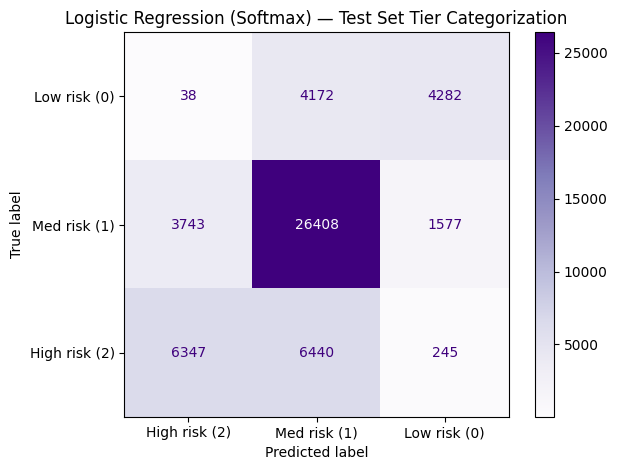

<Figure size 600x500 with 0 Axes>

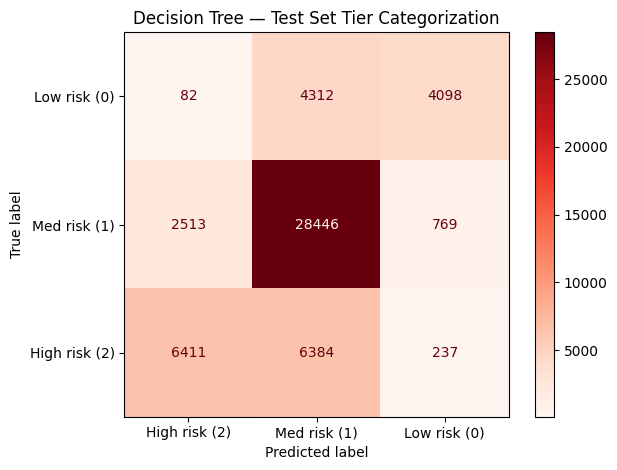

<Figure size 600x500 with 0 Axes>

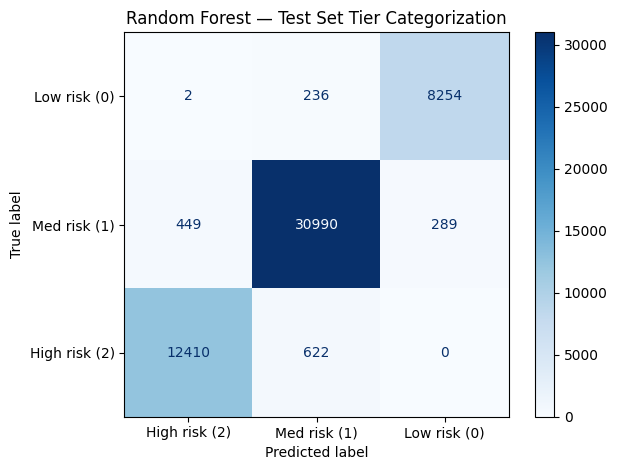

In [ ]:
# 7. Visualizations - here we plot our results as confusion matrices
tier_labels = ["Low risk (0)", "Med risk (1)", "High risk (2)"]

# Logistic Regression Confusion Matrix 
cm_log = confusion_matrix(y_test, y_pred_log, labels=[0, 1, 2])
# Reverse the columns for x-axis reversal
cm_log_reversed = cm_log[:, ::-1]

# Create custom display with reversed labels for x-axis
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log_reversed, 
                                  display_labels=tier_labels[::-1])

plt.figure(figsize=(6, 5))
disp_log.plot(cmap="Purples", values_format="d")
plt.title("Logistic Regression (Softmax) — Test Set Tier Categorization")

# Manually set the y-axis labels in the correct order
ax = plt.gca()
ax.set_yticklabels(tier_labels)
ax.set_xticklabels(tier_labels[::-1])  # Keep x-axis reversed

plt.tight_layout()
plt.show()

# Decision Tree Confusion Matrix 
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=[0, 1, 2])
cm_dt_reversed = cm_dt[:, ::-1]

disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt_reversed, 
                                 display_labels=tier_labels[::-1])

plt.figure(figsize=(6, 5))
disp_dt.plot(cmap="Reds", values_format="d")
plt.title("Decision Tree — Test Set Tier Categorization")

ax = plt.gca()
ax.set_yticklabels(tier_labels)
ax.set_xticklabels(tier_labels[::-1])

plt.tight_layout()
plt.show()

# Random Forest Confusion Matrix 
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1, 2])
cm_rf_reversed = cm_rf[:, ::-1]

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf_reversed, 
                                 display_labels=tier_labels[::-1])

plt.figure(figsize=(6, 5))
disp_rf.plot(cmap="Blues", values_format="d")
plt.title("Random Forest — Test Set Tier Categorization")

ax = plt.gca()
ax.set_yticklabels(tier_labels)
ax.set_xticklabels(tier_labels[::-1])

plt.tight_layout()
plt.show()




Logistic regression provides a solid linear baseline but struggles with Tier 0 and Tier 2 due to its limited capacity to model non-linear patterns. It performs best on the majority Tier 1 class, with noticeably lower recall for high-risk feeders.

The decision tree improves on logistic regression by capturing non-linear thresholds, especially boosting Tier 1 performance, but still misses many Tier 0 and Tier 2 cases. Its overall performance is moderate, reflecting the limitations of using a shallow, interpretable model on a complex classification task.

The random forest achieves excellent performance across all tiers, with high precision, recall, and F1, indicating strong ability to capture complex interactions in the data. Its consistently high scores suggest far better predictive power, though it may risk overfitting compared to simpler models.


## Resource Allocation and Conclusions (20 points)

The purpose of this project was to see whether feeder-level headroom and congestion risk could be predicted using publicly available data on load, weather, customer mix, and DER adoption. The three prediction problems taken together show that feeder behavior is patterned enough that models can provide useful guidance, although with meaningful uncertainty. The Random Forest generally performed better than linear models in every task, suggesting that congestion depends on interactions across several variables rather than simple trends. These results help link the forecasts to practical decisions about where to invest limited utility resources, which feeders should be monitored more closely, and where new DER projects are most likely to be feasible.

For the first prediction problem, the model estimating month-hour feeder load gives planners a rough sense of how much headroom remains before reaching a thermal or ICA limit. The Random Forest model’s errors were approximately 240 kW, which is small compared to feeders in the 10 to 15 MW range. This accuracy allows planners to use the predictions as one input when reviewing DER interconnection requests or assessing whether a feeder might need additional support. For instance, if a feeder has a 12 MW limit and the model predicts a load near 10.5 MW, that suggests that a small solar project or EV charger could likely be approved without major concern. If the forecast is closer to 11.7 or 11.8 MW, the feeder may need a closer look or a more conservative upgrade timeline. These insights can help prevent unnecessary upgrades, reduce delays, and direct funds toward feeders that appear to be trending toward constraint.

For the second prediction problem, the tuned Random Forest model delivered near-perfect performance, with an accuracy of 97.95%, precision of 96.52%, recall of 95.06%, and a ROC–AUC of 0.997. From a resource allocation perspective, the most important metric is recall, because false negatives represent missed congested feeders that can lead to interconnection delays, emergency upgrades, and reliability failures. With over 95% of truly congested cases correctly identified, the model allows utilities to confidently prioritize field inspections, targeted upgrades, and operational mitigation on feeders flagged as congested, while safely deferring action on feeders predicted to be uncongested. Quantitatively, this level of performance sharply reduces the risk of under-investment in constrained areas while avoiding unnecessary upgrades on low-risk feeders. In practice, this enables planners to shift from conservative system-wide spending toward highly targeted, feeder-specific investment, improving both cost efficiency and system reliability under growing electrification pressure.

The third prediction problem assigns observations into low, medium, or high congestion tiers, which helps longer-term planning and triage. The Random Forest captured the majority of high-risk cases, while simpler models struggled. If a feeder repeatedly falls into the highest-risk tier, that suggests it should be considered seriously for future capital planning. Feeders that sit mainly in the middle tier might not require immediate upgrades but could become riskier as electrification and DER adoption increase. This tiered approach helps utilities organize multi-year budgets and identify which locations may need more detailed engineering study.

Despite the strong performance of the Random Forest models, there are several sources of uncertainty that limit how confidently the results should be interpreted. The data were aggregated to the month-hour level, which smooths out sharp load spikes and extreme weather events. This means that true peak stress may be higher than the model predicts. EV adoption data were only available annually at the ZIP code level, and this likely understates short-term charging impacts. Weather data were matched to feeders through ZIP codes and regional weather stations, which may not fully capture local microclimates. These factors tend to bias estimates downward, suggesting that the model may understate congestion during unusual or extreme conditions.

The models are also purely data-driven. They do not enforce power system physics such as thermal limits, voltage performance, protection behavior, or feeder topology. If future operating conditions differ significantly from the historical data, such as rapid electrification or very high DER penetration, the models may not generalize well. The tiered classification problem is affected by class imbalance, making it easier for some models to default to the most common category. Even the Random Forest, though more accurate, may still overfit feeder-specific behaviors that would not transfer to other systems or future years.

Taken together, these limitations suggest that the results should be treated as helpful planning guidance rather than exact operational predictions. The uncertainty generally leans toward underestimating congestion risk, meaning that feeders identified as high-risk should be taken seriously, while feeders labeled low-risk should still be monitored with some caution. Even with these caveats, the models provide a practical and lightweight way to complement engineering studies and help program administrators deploy storage and load shifting programs, while helping utilities manage DER growth by modeling various scenarios with forecasted feature data. By bypassing the high operational costs associated with ICA map production, stakeholders can more quickly and cost-effectively identify where to focus their limited resources.
